# Classifying MTG Decks with Set Transformers


This notebook starts from precomputed hybrid card embeddings and fine-tunes a Set Transformer to score Commander decks.
The flow is intentionally split into smaller steps: load embeddings, normalize the deck corpora, build the permutation-invariant model, train on bracket labels, and then calibrate on tournament finishes.


In [135]:
import contextlib
import copy
import json
import random
import re
import unicodedata
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import kendalltau
from torch.utils.data import DataLoader, Dataset, Subset, random_split

try:
    from torch.utils.tensorboard import SummaryWriter
except Exception:
    SummaryWriter = None

### 1: Embeddings


We use precomputed hybrid card vectors (Word2Vec co-occurrence + MiniLM Oracle semantics).
These vectors become the base card representation for all downstream set modeling and are fine-tuned during supervised phases.

Because those embeddings are already pretrained, this notebook does not reload the embedding corpus or rerun embedding pretraining.


In [ ]:
import itertools

HYBRID_EMBED_PATH = Path("../embeddings/embedding-models/896dim_oracle_embeddings.pt")
SUPERVISED_JSONL = Path("../../data/training/training_corpus.jsonl")
TOURNAMENT_JSONL = Path("../../data/validation/validation_corpus.jsonl")
CHECKPOINT_DIR = Path("./checkpoints")
SEARCH_LOG_DIR = CHECKPOINT_DIR / "search_logs"

MAX_DECK_LEN = 115
MAX_QTY_EMBED = 40
BATCH_SIZE = 64
SEED = 42

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SEARCH_LOG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------
# Central Runtime Configuration
# ------------------------------
# PIPELINE_MODE options: "train", "load_checkpoint"
PIPELINE_MODE = "load_checkpoint"
CHECKPOINT_TO_LOAD = CHECKPOINT_DIR / "set_transformer_calibrated.pt"

RUN_HPARAM_SEARCH = False
RUN_CURRICULUM = False
RUN_EVAL_AFTER_PIPELINE = True
RUN_PHASE4_ANCHOR_STRETCH = False

MASTER_RUN_NAME = "set_transformer_master_run"

# Performance settings
USE_AMP = True
AMP_DTYPE = "bf16"  # "bf16" preferred on modern GPUs, fallback to fp16 if unsupported.
USE_ONECYCLE_LR = True
ONECYCLE_WARMUP_PCT = 0.10

# Search logging settings
ENABLE_SEARCH_JSONL_LOG = True
ENABLE_SEARCH_TENSORBOARD = False

DEFAULT_CONFIG = {
    "hidden_dim": 512,
    "num_heads": 8,
    "num_blocks": 4,
    "num_pma_seeds": 4,
    "batch_size": BATCH_SIZE,
    "lr_phase1": 2e-4,
    "lr_phase2": 1e-4,
    "lr_phase3": 5e-5,
    "dropout": 0.10,
    "delta": 0.75,
    "margin": 0.10,
    "trainable_last_blocks": 1,
    "max_qty_embed": MAX_QTY_EMBED,
}

# Search space (used when RUN_HPARAM_SEARCH=True)
grid_space = {
    "margin": [0.10, 0.05, 0.01],
    "delta": [1.00, 0.75, 0.50],
    "dropout": [0.10, 0.15, 0.20],
    "lr_phase3": [5e-5, 1e-5],
}

SEARCH_SUP_MAX_ITEMS = 15000
SEARCH_TOUR_MAX_ITEMS = 400
SEARCH_PHASE1_EPOCHS = 1
SEARCH_PHASE2_EPOCHS = 2
SEARCH_PHASE3_EPOCHS = 2

# Full curriculum budgets (used when RUN_CURRICULUM=True)
TRAIN_SUP_MAX_ITEMS = None
TRAIN_TOUR_MAX_ITEMS = None
TRAIN_PHASE1_EPOCHS = 8
TRAIN_PHASE2_EPOCHS = 12
TRAIN_PHASE3_EPOCHS = 5

In [137]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_hybrid_embeddings(path: Path) -> Tuple[Dict[str, int], torch.Tensor]:
    blob = torch.load(path, map_location="cpu")
    vocab = blob["vocab"]
    weights = blob["weights"].float()
    print(f"Loaded hybrid embeddings: vocab={len(vocab)}, dim={weights.shape[1]}")
    return vocab, weights


set_seed(SEED)
vocab, pretrained_weights = load_hybrid_embeddings(HYBRID_EMBED_PATH)
VOCAB_SIZE = len(vocab)
CARD_EMBED_DIM = pretrained_weights.shape[1]


Loaded hybrid embeddings: vocab=30156, dim=896


### 2: Preparing the Dataset

We load decklists as unordered sets of card IDs with quantity IDs and a padding mask so the model can attend over variable-size sets.


The notebook needs to handle two deck schemas.
The supervised corpus stores cards as a single `cards` dictionary, while the tournament corpus stores `main` and `cmds` as lists of `{name, qty}` records.
We normalize both into the same `(card_name, qty)` representation before tokenization.


In [ ]:
def normalize_card_name(name: str) -> str:
    name = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode("ascii")
    name = name.lower().strip()
    name = re.sub(r"^a-", "", name)
    name = re.sub(r"\s+", " ", name)
    front_face = re.split(r"\s*//\s*", name)[0]
    return front_face.strip()

In [139]:
def extend_zone_cards(cards_out: List[Tuple[str, int]], zone_cards) -> None:
    if isinstance(zone_cards, dict):
        for name, qty in zone_cards.items():
            cards_out.append((name, int(qty)))
    elif isinstance(zone_cards, list):
        for item in zone_cards:
            if isinstance(item, dict) and item.get("name") is not None:
                cards_out.append((item["name"], int(item.get("qty", 1))))
            elif item is not None:
                cards_out.append((str(item), 1))


def extract_card_qty_pairs(deck_obj: Dict) -> List[Tuple[str, int]]:
    cards_out: List[Tuple[str, int]] = []

    if isinstance(deck_obj.get("cards"), dict):
        for name, qty in deck_obj["cards"].items():
            cards_out.append((name, int(qty)))
    else:
        for zone in ("cards", "main", "cmds", "mainboard", "sideboard"):
            extend_zone_cards(cards_out, deck_obj.get(zone))

    filtered: List[Tuple[str, int]] = []
    for card_name, qty in cards_out:
        normalized = normalize_card_name(card_name)
        if qty <= 0:
            continue
        filtered.append((normalized, qty))
    return filtered


We keep two dataset views.
`DeckSetDataset` is used for bracket regression, and `TournamentEventDataset` groups decks by `event_url` so Phase 3 only compares decks from the same event.


In [140]:
class DeckSetDataset(Dataset):
    def __init__(
        self,
        jsonl_path: Path,
        vocab: Dict[str, int],
        max_len: int = MAX_DECK_LEN,
        label_field: Optional[str] = None,
        default_label: Optional[float] = None,
        source_prefix: Optional[str] = None,
    ):
        self.vocab = vocab
        self.max_len = max_len
        self.inputs = []
        self.quantities = []
        self.masks = []
        self.labels = []
        self.is_auto = []

        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                data = json.loads(line)

                if source_prefix is not None:
                    source = str(data.get("source", ""))
                    if not source.startswith(source_prefix):
                        continue

                target_value: Optional[float] = None
                if label_field is not None:
                    raw = data.get(label_field, default_label)
                    if raw is None:
                        continue
                    try:
                        target_value = float(raw)
                    except (TypeError, ValueError):
                        continue
                elif default_label is not None:
                    target_value = float(default_label)

                card_qty_pairs = extract_card_qty_pairs(data)
                if len(card_qty_pairs) < 10:
                    continue

                card_ids = []
                qty_ids = []
                for card_name, qty in card_qty_pairs:
                    card_ids.append(self.vocab.get(card_name, 1))
                    qty_ids.append(max(1, min(int(qty), MAX_QTY_EMBED)))

                card_ids = card_ids[: self.max_len]
                qty_ids = qty_ids[: self.max_len]
                mask = [1] * len(card_ids)

                pad_len = self.max_len - len(card_ids)
                if pad_len > 0:
                    card_ids += [0] * pad_len
                    qty_ids += [0] * pad_len
                    mask += [0] * pad_len

                self.inputs.append(card_ids)
                self.quantities.append(qty_ids)
                self.masks.append(mask)
                if target_value is not None:
                    self.labels.append(target_value)
                    self.is_auto.append(data.get("is_autobracket", False))

        self.inputs = torch.tensor(self.inputs, dtype=torch.long)
        self.quantities = torch.tensor(self.quantities, dtype=torch.long)
        self.masks = torch.tensor(self.masks, dtype=torch.bool)
        if self.labels:
            self.labels = torch.tensor(self.labels, dtype=torch.float32)
            self.is_auto = torch.tensor(self.is_auto, dtype=torch.bool)
        else:
            self.labels = None
            self.is_auto = None

        label_msg = f", labels={len(self.labels)}" if self.labels is not None else ""
        print(f"Loaded {len(self.inputs)} decks from {jsonl_path}{label_msg}")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        item = {
            "card_ids": self.inputs[idx],
            "qty_ids": self.quantities[idx],
            "mask": self.masks[idx],
        }
        if self.labels is not None:
            item["target"] = self.labels[idx]
            item["is_auto"] = self.is_auto[idx]
        return item


In [141]:
class TournamentEventDataset(Dataset):
    """
    Groups decks by event_url so each item is one full tournament event.
    """

    def __init__(self, jsonl_path: Path, vocab: Dict[str, int], max_len: int = MAX_DECK_LEN):
        self.vocab = vocab
        self.max_len = max_len
        self.events: Dict[str, List[Dict[str, object]]] = {}

        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                data = json.loads(line)

                event_url = data.get("event_url")
                placement = data.get("placement")
                if not event_url or placement is None:
                    continue

                try:
                    placement_value = float(placement)
                except (TypeError, ValueError):
                    continue

                card_qty_pairs = extract_card_qty_pairs(data)
                if len(card_qty_pairs) < 10:
                    continue

                card_ids = []
                qty_ids = []
                for card_name, qty in card_qty_pairs:
                    card_ids.append(self.vocab.get(card_name, 1))
                    qty_ids.append(max(1, min(int(qty), MAX_QTY_EMBED)))

                card_ids = card_ids[: self.max_len]
                qty_ids = qty_ids[: self.max_len]
                mask = [1] * len(card_ids)

                pad_len = self.max_len - len(card_ids)
                if pad_len > 0:
                    card_ids += [0] * pad_len
                    qty_ids += [0] * pad_len
                    mask += [0] * pad_len

                self.events.setdefault(str(event_url), []).append(
                    {
                        "card_ids": card_ids,
                        "qty_ids": qty_ids,
                        "mask": mask,
                        "placement": placement_value,
                    }
                )

        self.event_list = [decks for decks in self.events.values() if len(decks) >= 2]
        print(f"Loaded {len(self.event_list)} valid tournament events from {jsonl_path}")

    def __len__(self):
        return len(self.event_list)

    def __getitem__(self, idx):
        return self.event_list[idx]


def tournament_collate_fn(batch):
    event_decks = batch[0]

    return {
        "card_ids": torch.tensor([d["card_ids"] for d in event_decks], dtype=torch.long),
        "qty_ids": torch.tensor([d["qty_ids"] for d in event_decks], dtype=torch.long),
        "mask": torch.tensor([d["mask"] for d in event_decks], dtype=torch.bool),
        "placement": torch.tensor([d["placement"] for d in event_decks], dtype=torch.float32),
    }


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

LOADER_NUM_WORKERS = 0
LOADER_PIN_MEMORY = True


def subset_dataset(dataset: Dataset, max_items: Optional[int] = None, seed: int = SEED):
    if max_items is None or len(dataset) <= max_items:
        return dataset

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:max_items].tolist()
    return Subset(dataset, indices)


def split_supervised_loader(
    dataset: Dataset,
    val_ratio: float = 0.1,
    batch_size: int = BATCH_SIZE,
    seed: int = SEED,
):
    if len(dataset) < 2:
        raise ValueError("Supervised dataset is too small to create train/val splits.")

    val_size = max(1, int(len(dataset) * val_ratio))
    val_size = min(val_size, len(dataset) - 1)
    train_size = len(dataset) - val_size

    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=LOADER_NUM_WORKERS,
        pin_memory=LOADER_PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=LOADER_NUM_WORKERS,
        pin_memory=LOADER_PIN_MEMORY,
    )
    return train_loader, val_loader


def split_tournament_loaders(
    dataset: Dataset,
    val_ratio: float = 0.2,
    seed: int = SEED,
):
    if len(dataset) < 2:
        raise ValueError("Tournament dataset is too small to create train/eval splits.")

    val_size = max(1, int(len(dataset) * val_ratio))
    val_size = min(val_size, len(dataset) - 1)
    train_size = len(dataset) - val_size

    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)
    train_loader = DataLoader(
        train_ds,
        batch_size=1,
        shuffle=True,
        collate_fn=tournament_collate_fn,
        num_workers=LOADER_NUM_WORKERS,
        pin_memory=LOADER_PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        collate_fn=tournament_collate_fn,
        num_workers=LOADER_NUM_WORKERS,
        pin_memory=LOADER_PIN_MEMORY,
    )
    return train_loader, val_loader

Using device: cuda


In [143]:
sup_dataset = DeckSetDataset(SUPERVISED_JSONL, vocab=vocab, max_len=MAX_DECK_LEN, label_field="bracket")
tour_dataset = TournamentEventDataset(TOURNAMENT_JSONL, vocab=vocab, max_len=MAX_DECK_LEN)

sup_train_loader, sup_val_loader = split_supervised_loader(sup_dataset, val_ratio=0.1)
tour_train_loader, tour_loader = split_tournament_loaders(tour_dataset, val_ratio=0.2)


Loaded 192436 decks from ..\..\data\training\training_corpus.jsonl, labels=192436
Loaded 935 valid tournament events from ..\..\data\validation\validation_corpus.jsonl


### 3: Model Architecture - True Set Transformer


This model is permutation invariant by design: no positional encoding is used anywhere.

Each card token starts as a quantity-aware vector:
$V_{input} = V_{card} + E_{qty}(count)$

We then pass set elements through stacked self-attention blocks (4 to 6 blocks), followed by PMA (Pooling by Multihead Attention) with learned seed vectors. The pooled deck representation is sent through an MLP regressor and constrained to the bracket range with:
$Output = 1 + 4 \cdot \sigma(x)$


In [144]:
def compute_tournament_tau_stats(model: nn.Module, loader: DataLoader):
    model.eval()
    all_taus = []

    with torch.no_grad():
        for batch in loader:
            card_ids = batch["card_ids"].to(device)
            qty_ids = batch["qty_ids"].to(device)
            mask = batch["mask"].to(device)
            actual_placements = batch["placement"].cpu().numpy()

            if len(actual_placements) < 3:
                continue

            predicted_scores = model(card_ids, qty_ids, mask).squeeze().cpu().numpy()
            tau, _ = kendalltau(predicted_scores, -actual_placements)
            if not np.isnan(tau):
                all_taus.append(float(tau))

    if not all_taus:
        return {
            "num_tournaments": 0,
            "mean_tau": float("nan"),
            "median_tau": float("nan"),
            "positive_corr_pct": float("nan"),
        }

    tau_array = np.array(all_taus, dtype=np.float32)
    return {
        "num_tournaments": int(len(all_taus)),
        "mean_tau": float(tau_array.mean()),
        "median_tau": float(np.median(tau_array)),
        "positive_corr_pct": float((tau_array > 0).mean() * 100.0),
    }


def save_model_checkpoint(model: nn.Module, config: Dict[str, object], metrics: Dict[str, float], path: Path):
    payload = {
        "model_state_dict": copy.deepcopy(model.state_dict()),
        "config": dict(config),
        "metrics": dict(metrics),
        "vocab_size": VOCAB_SIZE,
        "card_embed_dim": CARD_EMBED_DIM,
        "max_qty": int(config.get("max_qty_embed", MAX_QTY_EMBED)),
    }
    torch.save(payload, path)
    print(f"Saved checkpoint to {path}")


def build_model(config: Dict[str, object]) -> MTGSetTransformerRegressor:
    max_qty_embed = int(config.get("max_qty_embed", MAX_QTY_EMBED))
    return MTGSetTransformerRegressor(
        vocab_size=VOCAB_SIZE,
        card_embed_dim=CARD_EMBED_DIM,
        hidden_dim=int(config.get("hidden_dim", 512)),
        num_heads=int(config.get("num_heads", 8)),
        num_blocks=int(config.get("num_blocks", 4)),
        num_pma_seeds=int(config.get("num_pma_seeds", 1)),
        max_qty=max_qty_embed,
        pretrained_weights=pretrained_weights,
        dropout=float(config.get("dropout", 0.1)),
    )

In [145]:
class PMALayer(nn.Module):
    def __init__(self, hidden_dim: int, num_heads: int, num_seeds: int = 1, dropout: float = 0.1):
        super().__init__()
        self.seed_vectors = nn.Parameter(torch.randn(1, num_seeds, hidden_dim) * 0.02)
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.ln = nn.LayerNorm(hidden_dim)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        queries = self.seed_vectors.expand(batch_size, -1, -1)
        pooled, _ = self.attn(
            queries,
            x,
            x,
            key_padding_mask=~mask,
            need_weights=False,
        )
        return self.ln(pooled)


In [146]:
class MTGSetTransformerRegressor(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        card_embed_dim: int,
        hidden_dim: int = 512,
        num_heads: int = 8,
        num_blocks: int = 4,
        num_pma_seeds: int = 1,
        max_qty: int = MAX_QTY_EMBED,
        pretrained_weights: Optional[torch.Tensor] = None,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.card_embedding = nn.Embedding(vocab_size, card_embed_dim, padding_idx=0)
        if pretrained_weights is not None:
            self.card_embedding.weight.data.copy_(pretrained_weights)

        self.card_proj = nn.Linear(card_embed_dim, hidden_dim)
        self.qty_embedding = nn.Embedding(max_qty + 1, hidden_dim, padding_idx=0)
        self.blocks = nn.ModuleList(
            [
                SetTransformerBlock(hidden_dim=hidden_dim, num_heads=num_heads, dropout=dropout)
                for _ in range(num_blocks)
            ]
        )
        self.pma = PMALayer(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            num_seeds=num_pma_seeds,
            dropout=dropout,
        )
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * num_pma_seeds, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        self.mlm_head = nn.Linear(hidden_dim, vocab_size)

    def encode_tokens(self, card_ids: torch.Tensor, qty_ids: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        card_vecs = self.card_embedding(card_ids)
        card_vecs = self.card_proj(card_vecs)

        qty_ids = qty_ids.clamp(min=0, max=self.qty_embedding.num_embeddings - 1)
        qty_vecs = self.qty_embedding(qty_ids)

        x = card_vecs + qty_vecs
        for block in self.blocks:
            x = block(x, mask)
        return x

    def forward_mlm(self, card_ids: torch.Tensor, qty_ids: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        token_reps = self.encode_tokens(card_ids, qty_ids, mask)
        return self.mlm_head(token_reps)

    def forward(self, card_ids: torch.Tensor, qty_ids: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        token_reps = self.encode_tokens(card_ids, qty_ids, mask)
        pooled = self.pma(token_reps, mask)
        pooled = pooled.reshape(pooled.size(0), -1)
        raw = self.regressor(pooled).squeeze(-1)
        return 1.0 + 4.0 * torch.sigmoid(raw)


def apply_mlm_mask(
    card_ids: torch.Tensor,
    mask: torch.Tensor,
    mask_token_id: int = 1,
    mask_ratio: float = 0.15,
    min_masked_per_deck: int = 1,
):
    masked_ids = card_ids.clone()
    labels = torch.full_like(card_ids, fill_value=-100)

    for i in range(card_ids.size(0)):
        valid_positions = torch.nonzero(mask[i], as_tuple=False).flatten()
        if valid_positions.numel() == 0:
            continue

        n_mask = max(min_masked_per_deck, int(valid_positions.numel() * mask_ratio))
        perm = torch.randperm(valid_positions.numel(), device=card_ids.device)[:n_mask]
        chosen = valid_positions[perm]

        labels[i, chosen] = card_ids[i, chosen]
        masked_ids[i, chosen] = mask_token_id

    return masked_ids, labels


### 4: Training - Supervised Curriculum


The card embeddings are already pretrained, but the Set Transformer still benefits from learning Commander deck geometry before it ever sees bracket targets.

Phase 1 masks cards inside EDH decklists so the attention blocks learn singleton Commander structure and competitive card synergy.
Phase 2 fits bracket targets with Huber loss to anchor the score scale.
Phase 3 freezes early attention blocks and uses pairwise tournament ranking inside each event to calibrate the top end of the latent space.


In [147]:
def _amp_enabled() -> bool:
    return bool(globals().get("USE_AMP", True) and device.type == "cuda")


def _amp_dtype() -> torch.dtype:
    pref = str(globals().get("AMP_DTYPE", "bf16")).lower()
    if pref == "fp16":
        return torch.float16
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
        return torch.bfloat16
    return torch.float16


def _autocast_context():
    if _amp_enabled():
        return torch.cuda.amp.autocast(dtype=_amp_dtype())
    return contextlib.nullcontext()


def _make_onecycle_scheduler(optimizer, lr: float, epochs: int, steps_per_epoch: int):
    if not globals().get("USE_ONECYCLE_LR", True):
        return None
    if epochs <= 0 or steps_per_epoch <= 0:
        return None
    warmup_pct = float(globals().get("ONECYCLE_WARMUP_PCT", 0.10))
    return optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=warmup_pct,
        anneal_strategy="cos",
        div_factor=25.0,
        final_div_factor=1e3,
    )


def train_phase1_mlm(
    model: nn.Module,
    loader: DataLoader,
    epochs: int = 2,
    lr: float = 2e-4,
):
    print("--- Starting Phase 1: Unsupervised MLM (EDH Only) ---")
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = _make_onecycle_scheduler(optimizer, lr=lr, epochs=epochs, steps_per_epoch=max(1, len(loader)))
    criterion = nn.CrossEntropyLoss(ignore_index=-100)
    amp_enabled = _amp_enabled()
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for batch in loader:
            card_ids = batch["card_ids"].to(device)
            qty_ids = batch["qty_ids"].to(device)
            mask = batch["mask"].to(device)

            masked_ids, labels = apply_mlm_mask(card_ids, mask, mask_token_id=1, mask_ratio=0.15)

            with _autocast_context():
                logits = model.forward_mlm(masked_ids, qty_ids, mask)
                loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()

            running_loss += float(loss.item())

        print(f"[Phase 1][Epoch {epoch + 1}] MLM loss: {running_loss / max(1, len(loader)):.4f}")


def evaluate_regression(model: nn.Module, loader: DataLoader, loss_fn: nn.Module) -> float:
    model.eval()
    total = 0.0
    with torch.no_grad():
        for batch in loader:
            card_ids = batch["card_ids"].to(device)
            qty_ids = batch["qty_ids"].to(device)
            mask = batch["mask"].to(device)
            target = batch["target"].to(device)

            with _autocast_context():
                pred = model(card_ids, qty_ids, mask)
                loss = loss_fn(pred, target)
            total += float(loss.item())
    model.train()
    return total / max(1, len(loader))


def pairwise_tournament_loss(
    pred: torch.Tensor,
    placements: torch.Tensor,
    margin: float = 0.1,
) -> torch.Tensor:
    diff_pred = pred.unsqueeze(1) - pred.unsqueeze(0)
    diff_placement = placements.unsqueeze(1) - placements.unsqueeze(0)

    target_sign = -torch.sign(diff_placement)
    valid_pairs = target_sign != 0
    if valid_pairs.sum() == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)

    losses = torch.relu(-target_sign[valid_pairs] * diff_pred[valid_pairs] + margin)
    return losses.mean()


def freeze_for_phase3(model: MTGSetTransformerRegressor, trainable_last_blocks: int = 1):
    for p in model.card_embedding.parameters():
        p.requires_grad = False
    for p in model.card_proj.parameters():
        p.requires_grad = False
    for p in model.qty_embedding.parameters():
        p.requires_grad = False

    n_blocks = len(model.blocks)
    freeze_count = max(0, n_blocks - trainable_last_blocks)
    for i in range(freeze_count):
        for p in model.blocks[i].parameters():
            p.requires_grad = False

In [148]:
def train_phase2_huber(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 6,
    lr: float = 1e-4,
    delta: float = 0.75,
    auto_penalty: float = 0.5,
):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = _make_onecycle_scheduler(optimizer, lr=lr, epochs=epochs, steps_per_epoch=max(1, len(train_loader)))
    train_loss_fn = nn.HuberLoss(delta=delta, reduction="none")
    eval_loss_fn = nn.HuberLoss(delta=delta, reduction="mean")
    amp_enabled = _amp_enabled()
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    model.train()

    for epoch in range(epochs):
        train_loss = 0.0
        for batch in train_loader:
            card_ids = batch["card_ids"].to(device)
            qty_ids = batch["qty_ids"].to(device)
            mask = batch["mask"].to(device)
            target = batch["target"].to(device)
            is_auto = batch.get("is_auto", torch.zeros_like(target, dtype=torch.bool)).to(device)
            weights = torch.where(is_auto, auto_penalty, 1.0)

            with _autocast_context():
                pred = model(card_ids, qty_ids, mask)
                unreduced_loss = train_loss_fn(pred, target)
                loss = (unreduced_loss * weights).mean()

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()

            train_loss += float(loss.item())

        val_loss = evaluate_regression(model, val_loader, eval_loss_fn)
        print(
            f"[Phase 2][Epoch {epoch + 1}] "
            f"Train Huber: {train_loss / max(1, len(train_loader)):.4f} | "
            f"Val Huber: {val_loss:.4f}"
        )

In [149]:
def train_phase3_tournament(
    model: MTGSetTransformerRegressor,
    loader: DataLoader,
    epochs: int = 4,
    lr: float = 5e-5,
    margin: float = 0.1,
    trainable_last_blocks: int = 1,
):
    freeze_for_phase3(model, trainable_last_blocks=trainable_last_blocks)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(params, lr=lr, weight_decay=1e-4)
    scheduler = _make_onecycle_scheduler(optimizer, lr=lr, epochs=epochs, steps_per_epoch=max(1, len(loader)))
    amp_enabled = _amp_enabled()
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for batch in loader:
            card_ids = batch["card_ids"].to(device)
            qty_ids = batch["qty_ids"].to(device)
            mask = batch["mask"].to(device)
            placements = batch["placement"].to(device)

            if card_ids.size(0) > 128:
                indices = torch.randperm(card_ids.size(0), device=card_ids.device)[:128]
                card_ids = card_ids.index_select(0, indices)
                qty_ids = qty_ids.index_select(0, indices)
                mask = mask.index_select(0, indices)
                placements = placements.index_select(0, indices)

            with _autocast_context():
                pred = model(card_ids, qty_ids, mask)
                loss = pairwise_tournament_loss(pred, placements, margin=margin)

            if loss.item() == 0.0:
                continue

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None:
                scheduler.step()

            running_loss += float(loss.item())

        print(f"[Phase 3][Epoch {epoch + 1}] Tournament Loss: {running_loss / max(1, len(loader)):.4f}")

The search below is intentionally bounded.
The supervised corpus is large enough that a full grid search would take a long time, so the notebook supports short exploratory searches on sampled subsets, saves every trial, and keeps the best checkpoint by held-out tournament Kendall tau.


### 4A: Runtime Configuration Walkthrough

This section is intentionally config-driven so the notebook can serve two workflows:
1. Train mode: run hyperparameter search and/or full curriculum from scratch.
2. Load checkpoint mode: skip training and go straight to evaluation/inference.

Key motivation: reproducibility and speed. You can keep one notebook for research, retraining, and lightweight model usage by only changing a few toggles.

In [150]:
def compute_tournament_tau_stats(model: nn.Module, loader: DataLoader):
    model.eval()
    all_taus = []

    with torch.no_grad():
        for batch in loader:
            card_ids = batch["card_ids"].to(device)
            qty_ids = batch["qty_ids"].to(device)
            mask = batch["mask"].to(device)
            actual_placements = batch["placement"].cpu().numpy()

            if len(actual_placements) < 3:
                continue

            predicted_scores = model(card_ids, qty_ids, mask).squeeze().cpu().numpy()
            tau, _ = kendalltau(predicted_scores, -actual_placements)
            if not np.isnan(tau):
                all_taus.append(float(tau))

    if not all_taus:
        return {
            "num_tournaments": 0,
            "mean_tau": float("nan"),
            "median_tau": float("nan"),
            "positive_corr_pct": float("nan"),
        }

    tau_array = np.array(all_taus, dtype=np.float32)
    return {
        "num_tournaments": int(len(all_taus)),
        "mean_tau": float(tau_array.mean()),
        "median_tau": float(np.median(tau_array)),
        "positive_corr_pct": float((tau_array > 0).mean() * 100.0),
    }


def save_model_checkpoint(model: nn.Module, config: Dict[str, object], metrics: Dict[str, float], path: Path):
    payload = {
        "model_state_dict": copy.deepcopy(model.state_dict()),
        "config": dict(config),
        "metrics": dict(metrics),
        "vocab_size": VOCAB_SIZE,
        "card_embed_dim": CARD_EMBED_DIM,
        "max_qty": MAX_QTY_EMBED,
    }
    torch.save(payload, path)
    print(f"Saved checkpoint to {path}")


def build_model(config: Dict[str, object]) -> MTGSetTransformerRegressor:
    return MTGSetTransformerRegressor(
        vocab_size=VOCAB_SIZE,
        card_embed_dim=CARD_EMBED_DIM,
        hidden_dim=int(config.get("hidden_dim", 512)),
        num_heads=int(config.get("num_heads", 8)),
        num_blocks=int(config.get("num_blocks", 4)),
        num_pma_seeds=int(config.get("num_pma_seeds", 1)),
        max_qty=MAX_QTY_EMBED,
        pretrained_weights=pretrained_weights,
        dropout=float(config.get("dropout", 0.1)),
    )


In [151]:
def _json_safe(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    return value


def append_search_jsonl(path: Path, record: Dict[str, object]):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, default=_json_safe) + "\n")


def run_training_trial(
    config: Dict[str, object],
    run_name: str,
    sup_max_items: Optional[int] = None,
    tour_max_items: Optional[int] = None,
    phase1_epochs: int = 8,
    phase2_epochs: int = 12,
    phase3_epochs: int = 5,
    supervised_val_ratio: float = 0.1,
    tournament_val_ratio: float = 0.2,
):
    config = dict(config)
    config.setdefault("max_qty_embed", MAX_QTY_EMBED)

    trial_sup_dataset = subset_dataset(sup_dataset, max_items=sup_max_items, seed=SEED)
    trial_tour_dataset = subset_dataset(tour_dataset, max_items=tour_max_items, seed=SEED)

    train_loader, val_loader = split_supervised_loader(
        trial_sup_dataset,
        val_ratio=supervised_val_ratio,
        batch_size=int(config.get("batch_size", BATCH_SIZE)),
        seed=SEED,
    )
    tour_train_loader, tour_eval_loader = split_tournament_loaders(
        trial_tour_dataset,
        val_ratio=tournament_val_ratio,
        seed=SEED,
    )
    mlm_loader = DataLoader(
        train_loader.dataset,
        batch_size=int(config.get("batch_size", BATCH_SIZE)),
        shuffle=True,
        num_workers=LOADER_NUM_WORKERS,
        pin_memory=True,
    )

    model = build_model(config).to(device)
    train_phase1_mlm(
        model,
        mlm_loader,
        epochs=phase1_epochs,
        lr=float(config.get("lr_phase1", 2e-4)),
    )
    print("\n--- Starting Phase 2: Supervised Huber Regression ---")
    train_phase2_huber(
        model,
        train_loader,
        val_loader,
        epochs=phase2_epochs,
        lr=float(config.get("lr_phase2", 1e-4)),
        delta=float(config.get("delta", 0.75)),
    )
    print("\n--- Starting Phase 3: Tournament Fine-Tuning ---")
    train_phase3_tournament(
        model,
        tour_train_loader,
        epochs=phase3_epochs,
        lr=float(config.get("lr_phase3", 5e-5)),
        margin=float(config.get("margin", 0.1)),
        trainable_last_blocks=int(config.get("trainable_last_blocks", 1)),
    )

    metrics = compute_tournament_tau_stats(model, tour_eval_loader)
    checkpoint_path = CHECKPOINT_DIR / f"{run_name}.pt"
    save_model_checkpoint(model, config, metrics, checkpoint_path)

    return {
        "model": model,
        "config": dict(config),
        "metrics": metrics,
        "checkpoint_path": checkpoint_path,
        "tour_eval_loader": tour_eval_loader,
    }


def run_hyperparameter_search(
    configs: List[Dict[str, object]],
    sup_max_items: Optional[int] = 30000,
    tour_max_items: Optional[int] = 600,
    phase1_epochs: int = 1,
    phase2_epochs: int = 2,
    phase3_epochs: int = 2,
):
    best_result = None
    best_score = -float("inf")

    search_jsonl_path = SEARCH_LOG_DIR / "hyperparam_trials.jsonl"
    tb_writer = None
    if ENABLE_SEARCH_TENSORBOARD and SummaryWriter is not None:
        tb_writer = SummaryWriter(log_dir=str(SEARCH_LOG_DIR / "tensorboard"))

    for idx, config in enumerate(configs, start=1):
        print("=" * 60)
        print(f"[Search {idx}/{len(configs)}] {config}")
        result = run_training_trial(
            config,
            run_name=f"set_transformer_trial_{idx}",
            sup_max_items=sup_max_items,
            tour_max_items=tour_max_items,
            phase1_epochs=phase1_epochs,
            phase2_epochs=phase2_epochs,
            phase3_epochs=phase3_epochs,
        )

        score = result["metrics"]["mean_tau"]
        print(f"Held-out mean tau: {score:.4f}")

        record = {
            "trial_index": idx,
            "num_trials": len(configs),
            "config": result["config"],
            "metrics": result["metrics"],
            "checkpoint_path": str(result["checkpoint_path"]),
        }
        if ENABLE_SEARCH_JSONL_LOG:
            append_search_jsonl(search_jsonl_path, record)
        if tb_writer is not None and not np.isnan(score):
            tb_writer.add_scalar("search/mean_tau", float(score), idx)
            tb_writer.add_scalar("search/median_tau", float(result["metrics"]["median_tau"]), idx)
            for key, value in result["config"].items():
                if isinstance(value, (int, float)):
                    tb_writer.add_scalar(f"config/{key}", float(value), idx)

        if not np.isnan(score) and score > best_score:
            best_score = score
            best_result = result
            best_path = CHECKPOINT_DIR / "best_set_transformer.pt"
            save_model_checkpoint(result["model"], result["config"], result["metrics"], best_path)

    if tb_writer is not None:
        tb_writer.close()

    if ENABLE_SEARCH_JSONL_LOG:
        print(f"Search trials logged to: {search_jsonl_path}")
    if ENABLE_SEARCH_TENSORBOARD and SummaryWriter is None:
        print("TensorBoard logging requested, but tensorboard is not available in this environment.")

    return best_result


def _load_state_with_qty_resize(model: nn.Module, state_dict: Dict[str, torch.Tensor]) -> None:
    model_state = model.state_dict()
    merged_state = dict(model_state)

    for key, value in state_dict.items():
        if key not in model_state:
            continue

        if key == "qty_embedding.weight" and value.shape != model_state[key].shape:
            merged = model_state[key].clone()
            rows = min(value.shape[0], merged.shape[0])
            merged[:rows] = value[:rows]
            merged_state[key] = merged
            print(
                f"Resized qty embedding during load: checkpoint_rows={value.shape[0]}, "
                f"model_rows={merged.shape[0]}"
            )
            continue

        if value.shape == model_state[key].shape:
            merged_state[key] = value

    model.load_state_dict(merged_state, strict=False)


def load_model_from_checkpoint(checkpoint_path: Path) -> Tuple[nn.Module, Dict[str, object]]:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    config = dict(checkpoint.get("config", {}))

    state_dict = checkpoint["model_state_dict"]
    ckpt_qty_rows = None
    if "qty_embedding.weight" in state_dict:
        ckpt_qty_rows = int(state_dict["qty_embedding.weight"].shape[0])
    ckpt_max_qty = int(checkpoint.get("max_qty", max(1, (ckpt_qty_rows or 1) - 1)))

    if "max_qty_embed" not in config:
        config["max_qty_embed"] = ckpt_max_qty

    loaded_model = build_model(config).to(device)
    _load_state_with_qty_resize(loaded_model, state_dict)
    loaded_model.eval()

    checkpoint["config"] = config
    checkpoint["max_qty"] = int(config.get("max_qty_embed", ckpt_max_qty))
    return loaded_model, checkpoint

In [152]:
# Build derived search configs from top-level constants/config only.
SEARCH_CONFIGS = []
keys = grid_space.keys()
for values in itertools.product(*grid_space.values()):
    config_update = dict(zip(keys, values))
    SEARCH_CONFIGS.append({**DEFAULT_CONFIG, **config_update})

print(f"Generated {len(SEARCH_CONFIGS)} search configurations.")

Generated 54 search configurations.


### 4B: Pipeline Orchestration

The next code cell executes the chosen runtime path.
1. If mode is load_checkpoint, it loads weights and config into memory.
2. If mode is train, it can run search first, then full curriculum using the selected config.
3. The selected checkpoint path is tracked so downstream cells can reuse it for inference and optional calibration.

In [153]:
def calibrate_score_minmax(
    raw_score: float,
    raw_min: float = 3.8,
    raw_max: float = 4.4,
    out_min: float = 1.0,
    out_max: float = 10.0,
    clip: bool = True,
) -> float:
    if raw_max <= raw_min:
        raise ValueError("raw_max must be greater than raw_min")

    scaled = ((raw_score - raw_min) / (raw_max - raw_min)) * (out_max - out_min) + out_min
    if clip:
        scaled = max(out_min, min(out_max, scaled))
    return float(scaled)


def predict_deck_power(deck_dict: Dict[str, int], model_path: Path) -> float:
    # Reuse robust checkpoint loader so legacy qty embedding shapes remain compatible.
    eval_model, _ = load_model_from_checkpoint(model_path)

    # Process the raw dictionary into model tensors
    card_ids = []
    qty_ids = []

    for name, qty in deck_dict.items():
        norm_name = normalize_card_name(name)
        if qty <= 0:
            continue
        card_ids.append(vocab.get(norm_name, 1))

        max_qty_for_model = eval_model.qty_embedding.num_embeddings - 1
        qty_ids.append(max(1, min(int(qty), max_qty_for_model)))

    card_ids = card_ids[:MAX_DECK_LEN]
    qty_ids = qty_ids[:MAX_DECK_LEN]
    mask = [1] * len(card_ids)

    pad_len = MAX_DECK_LEN - len(card_ids)
    if pad_len > 0:
        card_ids += [0] * pad_len
        qty_ids += [0] * pad_len
        mask += [0] * pad_len

    c_tensor = torch.tensor([card_ids], dtype=torch.long).to(device)
    q_tensor = torch.tensor([qty_ids], dtype=torch.long).to(device)
    m_tensor = torch.tensor([mask], dtype=torch.bool).to(device)

    with torch.no_grad():
        score = eval_model(c_tensor, q_tensor, m_tensor).item()

    return score


# --- Test Packages ---

# 1. The Precon/Battlecruiser Package (Taplands, expensive spells, vanilla creatures)
battlecruiser_package = {"swamp": 25, "arcane signet": 1, "ayara, first of locthwain": 1, "syr konrad, the grim": 1, "pack rat": 1, "black market": 1, "dark ritual": 1, "dictate of erebos": 1, "gray merchant of asphodel": 1, "gruesome fate": 1, "herald's horn": 1, "living death": 1, "skullclamp": 1, "sol ring": 1, "village rites": 1, "marrow-gnawer": 1, "grave pact": 1, "darkness": 1, "culling the weak": 1, "cabal coffers": 1, "patriarch's bidding": 1, "diabolic intent": 1, "urborg, tomb of yawgmoth": 1, "secret salvage": 1, "altar of dementia": 1, "jet medallion": 1, "bontu's monument": 1, "cover of darkness": 1, "swarmyard": 1, "crypt of agadeem": 1, "cabal stronghold": 1, "vanquisher's banner": 1, "nykthos, shrine to nyx": 1, "imp's mischief": 1, "commander's plate": 1, "echoing return": 1, "deadly dispute": 1, "the meathook massacre": 1, "ashcoat of the shadow swarm": 1, "corrupted conviction": 1, "eviscerator's insight": 1, "ripples of undeath": 1, "mudflat village": 1, "three tree city": 1, "valley rotcaller": 1, "swarmyard massacre": 1, "banner of kinship": 1, "chronicle of victory": 1, "grave venerations": 1, "gathering stone": 1, "bloodline bidding": 1, "piper of the swarm": 1, "rat colony": 23, "rat king, verminister": 1}

# 2. The High-Power Casual Package (Good synergy, solid interaction, fair mana)
high_power_package = {"fabled passage": 1, "seedborn muse": 1, "animate dead": 1, "liliana, the last hope": 1, "splendid reclamation": 1, "rise from the grave": 1, "swamp": 8, "lotus petal": 1, "altar of dementia": 1, "spore frog": 1, "lightning greaves": 1, "buried alive": 1, "mesmeric orb": 1, "island": 7, "garruk wildspeaker": 1, "rampaging baloths": 1, "sidisi, brood tyrant": 1, "hissing quagmire": 1, "gravecrawler": 1, "unearth": 1, "tatyova, benthic druid": 1, "eternal witness": 1, "farseek": 1, "hedron crab": 1, "lotus cobra": 1, "victimize": 1, "muldrotha, the gravetide": 1, "diregraf rebirth": 1, "curse of the restless dead": 1, "kessig cagebreakers": 1, "liliana, death's majesty": 1, "reclusive taxidermist": 1, "persistent specimen": 1, "dreadhound": 1, "return to nature": 1, "rootcoil creeper": 1, "gale, waterdeep prodigy": 1, "havengul lich": 1, "woodland cemetery": 1, "worldly tutor": 1, "exploration": 1, "frantic search": 1, "lull": 1, "remote isle": 1, "forest": 8, "glissa sunslayer": 1, "phyrexian arena": 1, "yarok, the desecrated": 1, "shire terrace": 1, "field of ruin": 1, "rise of the witch-king": 1, "entish restoration": 1, "the grey havens": 1, "shower of arrows": 1, "basalt monolith": 1, "command tower": 1, "dread return": 1, "blooming marsh": 1, "quest for the necropolis": 1, "llanowar wastes": 1, "cascading cataracts": 1, "chromatic lantern": 1, "iridescent vinelasher": 1, "valgavoth's faithful": 1, "hedge shredder": 1, "jungle hollow": 1, "deadly allure": 1, "wastewood verge": 1, "the scarab god": 1, "broodheart engine": 1, "sidisi, regent of the mire": 1, "roamer's routine": 1, "kotis, sibsig champion": 1, "opulent palace": 1, "jarad, golgari lich lord": 1, "lord of the forsaken": 1, "ob nixilis, the fallen": 1, "dragon sniper": 1, "the gitrog monster": 1, "teval, the balanced scale": 1}

# 3. The cEDH Package (Fast mana, free interaction, efficient combo)
cedh_package = {"wishclaw talisman": 1, "ghostly pilferer": 1, "cabal ritual": 1, "insidious dreams": 1, "putrid imp": 1, "grinding station": 1, "forbidden orchard": 1, "mnemonic betrayal": 1, "rite of flame": 1, "brain freeze": 1, "ancient tomb": 1, "lotus petal": 1, "frantic search": 1, "grim monolith": 1, "snap": 1, "mana vault": 1, "red elemental blast": 1, "mana confluence": 1, "mental misstep": 1, "ad nauseam": 1, "one with nothing": 1, "rhystic study": 1, "firestorm": 1, "attunement": 1, "dark ritual": 1, "gamble": 1, "rain of filth": 1, "yawgmoth's will": 1, "windfall": 1, "final fortune": 1, "lion's eye diamond": 1, "mystical tutor": 1, "demonic consultation": 1, "mystic remora": 1, "necropotence": 1, "pyroblast": 1, "badlands": 1, "demonic tutor": 1, "underground sea": 1, "volcanic island": 1, "wheel of fortune": 1, "thassa's oracle": 1, "force of will": 1, "mox diamond": 1, "bloodstained mire": 1, "chain of vapor": 1, "flooded strand": 1, "polluted delta": 1, "gemstone caverns": 1, "simian spirit guide": 1, "city of brass": 1, "cephalid coliseum": 1, "tainted pact": 1, "birgi, god of storytelling": 1, "pact of negation": 1, "chromatic star": 1, "marsh flats": 1, "misty rainforest": 1, "scalding tarn": 1, "verdant catacombs": 1, "arcane signet": 1, "malevolent hermit": 1, "otawara, soaring city": 1, "praetor's grasp": 1, "jeska's will": 1, "imperial seal": 1, "talisman of creativity": 1, "talisman of dominance": 1, "talisman of indulgence": 1, "chain of smog": 1, "command tower": 1, "chrome mox": 1, "dramatic reversal": 1, "fellwar stone": 1, "faithless looting": 1, "diabolic intent": 1, "defense grid": 1, "mox amber": 1, "vampiric tutor": 1, "orcish bowmasters": 1, "deflecting swat": 1, "fierce guardianship": 1, "beseech the mirror": 1, "sol ring": 1, "mox opal": 1, "blood crypt": 1, "steam vents": 1, "watery grave": 1, "undercity sewers": 1, "flusterstorm": 1, "ragavan, nimble pilferer": 1, "valley floodcaller": 1, "into the flood maw": 1, "demonic counsel": 1, "an offer you can't refuse": 1, "underworld breach": 1, "starting town": 1, "redirect lightning": 1, "borne upon a wind": 1, "norman osborn": 1}

# Run the tests
master_checkpoint = CHECKPOINT_DIR / "set_transformer_master_run.pt"

if master_checkpoint.exists():
    print("=" * 46)
    print("MODEL SANITY CHECK (RAW + CALIBRATED)")
    print("=" * 46)

    raw_battlecruiser = predict_deck_power(battlecruiser_package, master_checkpoint)
    raw_high_power = predict_deck_power(high_power_package, master_checkpoint)
    raw_cedh = predict_deck_power(cedh_package, master_checkpoint)

    cal_battlecruiser = calibrate_score_minmax(raw_battlecruiser)
    cal_high_power = calibrate_score_minmax(raw_high_power)
    cal_cedh = calibrate_score_minmax(raw_cedh)

    print(f"Battlecruiser Package -> raw: {raw_battlecruiser:.2f} | calibrated: {cal_battlecruiser:.2f}/10")
    print(f"High-Power Casual   -> raw: {raw_high_power:.2f} | calibrated: {cal_high_power:.2f}/10")
    print(f"cEDH Combo Package  -> raw: {raw_cedh:.2f} | calibrated: {cal_cedh:.2f}/10")
    print("-" * 46)
    print("Calibration defaults: raw_min=3.8, raw_max=4.4, output=1..10")
else:
    print("Master run checkpoint not found. Please verify the file path.")

MODEL SANITY CHECK (RAW + CALIBRATED)
Resized qty embedding during load: checkpoint_rows=9, model_rows=41
Resized qty embedding during load: checkpoint_rows=9, model_rows=41
Resized qty embedding during load: checkpoint_rows=9, model_rows=41
Battlecruiser Package -> raw: 3.96 | calibrated: 3.35/10
High-Power Casual   -> raw: 4.09 | calibrated: 5.33/10
cEDH Combo Package  -> raw: 4.37 | calibrated: 9.50/10
----------------------------------------------
Calibration defaults: raw_min=3.8, raw_max=4.4, output=1..10


### 5: Evaluation - Tournament Rank Correlation

To evaluate how well our model learned to evaluate competitive EDH decks, we use Kendall's Rank Correlation Coefficient ($\tau$).
For each tournament event in our validation set, we ask the model to score the decks. We then compare the model's predicted ranking against the actual tournament placements.


In [154]:
from scipy.stats import kendalltau
import numpy as np


def evaluate_tournament_ranking(model: nn.Module, loader: DataLoader):
    """
    Evaluates the model's ability to predict tournament placements using Kendall's Tau.
    """
    model.eval()
    all_taus = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            card_ids = batch["card_ids"].to(device)
            qty_ids = batch["qty_ids"].to(device)
            mask = batch["mask"].to(device)
            actual_placements = batch["placement"].cpu().numpy()

            # Skip tournaments with fewer than 3 decks (correlation isn't very meaningful)
            if len(actual_placements) < 3:
                continue

            # Get model's continuous power predictions
            predicted_scores = model(card_ids, qty_ids, mask).squeeze().cpu().numpy()

            # Kendall's Tau expects both arrays to be ordered the same way (e.g., higher is better).
            # Because a LOWER placement integer (1st place) is BETTER, we must negate the actual placements
            # so that 1st place (-1) is mathematically greater than 16th place (-16), matching our predicted power scores.
            inverted_placements = -actual_placements

            # Calculate Kendall's Tau
            tau, p_value = kendalltau(predicted_scores, inverted_placements)

            # Handle cases where tau is NaN (e.g., model predicted the exact same score for all decks)
            if not np.isnan(tau):
                all_taus.append(tau)

    if not all_taus:
        print("Not enough valid tournaments to calculate correlation.")
        return

    mean_tau = np.mean(all_taus)
    median_tau = np.median(all_taus)
    positive_corr_pct = (np.array(all_taus) > 0).mean() * 100

    print("=" * 40)
    print("Tournament Ranking Evaluation")
    print("=" * 40)
    print(f"Total Tournaments Evaluated: {len(all_taus)}")
    print(f"Mean Kendall's Tau:          {mean_tau:.4f}")
    print(f"Median Kendall's Tau:        {median_tau:.4f}")
    print(f"Tournaments w/ Positive Corr:{positive_corr_pct:.1f}%")
    print("-" * 40)

    # Contextualizing the results
    if mean_tau > 0.4:
        print("Verdict: Excellent. The model strongly understands the cEDH meta.")
    elif mean_tau > 0.2:
        print("Verdict: Good. The model has a solid grasp of deck power levels.")
    elif mean_tau > 0.0:
        print("Verdict: Weak. The model is slightly better than random guessing.")
    else:
        print("Verdict: Failed. The model's predictions are inverted or entirely random.")


In [155]:
# Optional held-out tournament evaluation after load/train orchestration.
if RUN_EVAL_AFTER_PIPELINE and model is not None:
    evaluate_tournament_ranking(model, tour_loader)
elif RUN_EVAL_AFTER_PIPELINE:
    print("Skipping evaluation: no model is available in memory.")

Skipping evaluation: no model is available in memory.



### 6: Sanity Check - Manual Deck Inference

Let's test the model's generalized understanding of power by feeding it distinct packages of cards. 
Because of the padding mask, we can feed it partial decks (e.g., 10-15 cards) to see how it scores specific synergies.

### 6A: Inference Usage Notes

The inference helper is designed to be checkpoint-agnostic.
1. You can pass any compatible checkpoint path (master run, best search, or calibrated).
2. This allows production-style usage where training is skipped and only prediction is needed.
3. The sanity decks remain here as executable examples and regression tests for model behavior.

In [156]:
def calibrate_score_minmax(
    raw_score: float,
    raw_min: float = 3.8,
    raw_max: float = 4.4,
    out_min: float = 1.0,
    out_max: float = 10.0,
    clip: bool = True,
) -> float:
    if raw_max <= raw_min:
        raise ValueError("raw_max must be greater than raw_min")

    scaled = ((raw_score - raw_min) / (raw_max - raw_min)) * (out_max - out_min) + out_min
    if clip:
        scaled = max(out_min, min(out_max, scaled))
    return float(scaled)


def predict_deck_power(deck_dict: Dict[str, int], model_path: Path) -> float:
    # 1. Load the checkpoint and rebuild the model
    checkpoint = torch.load(model_path, map_location=device)
    eval_model = build_model(checkpoint["config"]).to(device)
    eval_model.load_state_dict(checkpoint["model_state_dict"])
    eval_model.eval()

    # 2. Process the raw dictionary into model tensors
    card_ids = []
    qty_ids = []

    for name, qty in deck_dict.items():
        norm_name = normalize_card_name(name)
        if qty <= 0:
            continue
        # Default to 1 (usually the UNK token) if card isn't in vocab
        card_ids.append(vocab.get(norm_name, 1))
        qty_ids.append(max(1, min(int(qty), MAX_QTY_EMBED)))

    # Truncate if somehow over max length
    card_ids = card_ids[:MAX_DECK_LEN]
    qty_ids = qty_ids[:MAX_DECK_LEN]
    mask = [1] * len(card_ids)

    # Pad to max length
    pad_len = MAX_DECK_LEN - len(card_ids)
    if pad_len > 0:
        card_ids += [0] * pad_len
        qty_ids += [0] * pad_len
        mask += [0] * pad_len

    # Convert to batch-of-1 tensors
    c_tensor = torch.tensor([card_ids], dtype=torch.long).to(device)
    q_tensor = torch.tensor([qty_ids], dtype=torch.long).to(device)
    m_tensor = torch.tensor([mask], dtype=torch.bool).to(device)

    # 3. Predict
    with torch.no_grad():
        score = eval_model(c_tensor, q_tensor, m_tensor).item()

    return score


# --- Test Packages ---

# 1. The Precon/Battlecruiser Package (Taplands, expensive spells, vanilla creatures)
battlecruiser_package = {"swamp": 25, "arcane signet": 1, "ayara, first of locthwain": 1, "syr konrad, the grim": 1, "pack rat": 1, "black market": 1, "dark ritual": 1, "dictate of erebos": 1, "gray merchant of asphodel": 1, "gruesome fate": 1, "herald's horn": 1, "living death": 1, "skullclamp": 1, "sol ring": 1, "village rites": 1, "marrow-gnawer": 1, "grave pact": 1, "darkness": 1, "culling the weak": 1, "cabal coffers": 1, "patriarch's bidding": 1, "diabolic intent": 1, "urborg, tomb of yawgmoth": 1, "secret salvage": 1, "altar of dementia": 1, "jet medallion": 1, "bontu's monument": 1, "cover of darkness": 1, "swarmyard": 1, "crypt of agadeem": 1, "cabal stronghold": 1, "vanquisher's banner": 1, "nykthos, shrine to nyx": 1, "imp's mischief": 1, "commander's plate": 1, "echoing return": 1, "deadly dispute": 1, "the meathook massacre": 1, "ashcoat of the shadow swarm": 1, "corrupted conviction": 1, "eviscerator's insight": 1, "ripples of undeath": 1, "mudflat village": 1, "three tree city": 1, "valley rotcaller": 1, "swarmyard massacre": 1, "banner of kinship": 1, "chronicle of victory": 1, "grave venerations": 1, "gathering stone": 1, "bloodline bidding": 1, "piper of the swarm": 1, "rat colony": 23, "rat king, verminister": 1}

# 2. The High-Power Casual Package (Good synergy, solid interaction, fair mana)
high_power_package = {"fabled passage": 1, "seedborn muse": 1, "animate dead": 1, "liliana, the last hope": 1, "splendid reclamation": 1, "rise from the grave": 1, "swamp": 8, "lotus petal": 1, "altar of dementia": 1, "spore frog": 1, "lightning greaves": 1, "buried alive": 1, "mesmeric orb": 1, "island": 7, "garruk wildspeaker": 1, "rampaging baloths": 1, "sidisi, brood tyrant": 1, "hissing quagmire": 1, "gravecrawler": 1, "unearth": 1, "tatyova, benthic druid": 1, "eternal witness": 1, "farseek": 1, "hedron crab": 1, "lotus cobra": 1, "victimize": 1, "muldrotha, the gravetide": 1, "diregraf rebirth": 1, "curse of the restless dead": 1, "kessig cagebreakers": 1, "liliana, death's majesty": 1, "reclusive taxidermist": 1, "persistent specimen": 1, "dreadhound": 1, "return to nature": 1, "rootcoil creeper": 1, "gale, waterdeep prodigy": 1, "havengul lich": 1, "woodland cemetery": 1, "worldly tutor": 1, "exploration": 1, "frantic search": 1, "lull": 1, "remote isle": 1, "forest": 8, "glissa sunslayer": 1, "phyrexian arena": 1, "yarok, the desecrated": 1, "shire terrace": 1, "field of ruin": 1, "rise of the witch-king": 1, "entish restoration": 1, "the grey havens": 1, "shower of arrows": 1, "basalt monolith": 1, "command tower": 1, "dread return": 1, "blooming marsh": 1, "quest for the necropolis": 1, "llanowar wastes": 1, "cascading cataracts": 1, "chromatic lantern": 1, "iridescent vinelasher": 1, "valgavoth's faithful": 1, "hedge shredder": 1, "jungle hollow": 1, "deadly allure": 1, "wastewood verge": 1, "the scarab god": 1, "broodheart engine": 1, "sidisi, regent of the mire": 1, "roamer's routine": 1, "kotis, sibsig champion": 1, "opulent palace": 1, "jarad, golgari lich lord": 1, "lord of the forsaken": 1, "ob nixilis, the fallen": 1, "dragon sniper": 1, "the gitrog monster": 1, "teval, the balanced scale": 1}

# 3. The cEDH Package (Fast mana, free interaction, efficient combo)
cedh_package = {"wishclaw talisman": 1, "ghostly pilferer": 1, "cabal ritual": 1, "insidious dreams": 1, "putrid imp": 1, "grinding station": 1, "forbidden orchard": 1, "mnemonic betrayal": 1, "rite of flame": 1, "brain freeze": 1, "ancient tomb": 1, "lotus petal": 1, "frantic search": 1, "grim monolith": 1, "snap": 1, "mana vault": 1, "red elemental blast": 1, "mana confluence": 1, "mental misstep": 1, "ad nauseam": 1, "one with nothing": 1, "rhystic study": 1, "firestorm": 1, "attunement": 1, "dark ritual": 1, "gamble": 1, "rain of filth": 1, "yawgmoth's will": 1, "windfall": 1, "final fortune": 1, "lion's eye diamond": 1, "mystical tutor": 1, "demonic consultation": 1, "mystic remora": 1, "necropotence": 1, "pyroblast": 1, "badlands": 1, "demonic tutor": 1, "underground sea": 1, "volcanic island": 1, "wheel of fortune": 1, "thassa's oracle": 1, "force of will": 1, "mox diamond": 1, "bloodstained mire": 1, "chain of vapor": 1, "flooded strand": 1, "polluted delta": 1, "gemstone caverns": 1, "simian spirit guide": 1, "city of brass": 1, "cephalid coliseum": 1, "tainted pact": 1, "birgi, god of storytelling": 1, "pact of negation": 1, "chromatic star": 1, "marsh flats": 1, "misty rainforest": 1, "scalding tarn": 1, "verdant catacombs": 1, "arcane signet": 1, "malevolent hermit": 1, "otawara, soaring city": 1, "praetor's grasp": 1, "jeska's will": 1, "imperial seal": 1, "talisman of creativity": 1, "talisman of dominance": 1, "talisman of indulgence": 1, "chain of smog": 1, "command tower": 1, "chrome mox": 1, "dramatic reversal": 1, "fellwar stone": 1, "faithless looting": 1, "diabolic intent": 1, "defense grid": 1, "mox amber": 1, "vampiric tutor": 1, "orcish bowmasters": 1, "deflecting swat": 1, "fierce guardianship": 1, "beseech the mirror": 1, "sol ring": 1, "mox opal": 1, "blood crypt": 1, "steam vents": 1, "watery grave": 1, "undercity sewers": 1, "flusterstorm": 1, "ragavan, nimble pilferer": 1, "valley floodcaller": 1, "into the flood maw": 1, "demonic counsel": 1, "an offer you can't refuse": 1, "underworld breach": 1, "starting town": 1, "redirect lightning": 1, "borne upon a wind": 1, "norman osborn": 1}

# Run the tests
master_checkpoint = CHECKPOINT_DIR / "set_transformer_master_run.pt"

if master_checkpoint.exists():
    print("=" * 46)
    print("MODEL SANITY CHECK (RAW + CALIBRATED)")
    print("=" * 46)

    raw_battlecruiser = predict_deck_power(battlecruiser_package, master_checkpoint)
    raw_high_power = predict_deck_power(high_power_package, master_checkpoint)
    raw_cedh = predict_deck_power(cedh_package, master_checkpoint)

    cal_battlecruiser = calibrate_score_minmax(raw_battlecruiser)
    cal_high_power = calibrate_score_minmax(raw_high_power)
    cal_cedh = calibrate_score_minmax(raw_cedh)

    print(f"Battlecruiser Package -> raw: {raw_battlecruiser:.2f} | calibrated: {cal_battlecruiser:.2f}/10")
    print(f"High-Power Casual   -> raw: {raw_high_power:.2f} | calibrated: {cal_high_power:.2f}/10")
    print(f"cEDH Combo Package  -> raw: {raw_cedh:.2f} | calibrated: {cal_cedh:.2f}/10")
    print("-" * 46)
    print("Calibration defaults: raw_min=3.8, raw_max=4.4, output=1..10")
else:
    print("Master run checkpoint not found. Please verify the file path.")

MODEL SANITY CHECK (RAW + CALIBRATED)


RuntimeError: Error(s) in loading state_dict for MTGSetTransformerRegressor:
	size mismatch for qty_embedding.weight: copying a param with shape torch.Size([9, 512]) from checkpoint, the shape in current model is torch.Size([41, 512]).

### 6B: Optional Native Scale Calibration (Phase 4)

This block is optional and controlled by configuration.
1. It freezes the representation layers and updates only the regressor head.
2. Motivation: preserve learned deck geometry while fixing absolute output scale.
3. Set RUN_PHASE4_ANCHOR_STRETCH=True in the config section to enable it.

In [ ]:
def deck_to_tensors(deck_dict: Dict[str, int]):
    card_ids = []
    qty_ids = []

    for name, qty in deck_dict.items():
        if qty <= 0:
            continue
        card_ids.append(vocab.get(normalize_card_name(name), 1))
        qty_ids.append(max(1, min(int(qty), MAX_QTY_EMBED)))

    card_ids = card_ids[:MAX_DECK_LEN]
    qty_ids = qty_ids[:MAX_DECK_LEN]
    mask = [1] * len(card_ids)

    pad_len = MAX_DECK_LEN - len(card_ids)
    if pad_len > 0:
        card_ids += [0] * pad_len
        qty_ids += [0] * pad_len
        mask += [0] * pad_len

    c_tensor = torch.tensor([card_ids], dtype=torch.long).to(device)
    q_tensor = torch.tensor([qty_ids], dtype=torch.long).to(device)
    m_tensor = torch.tensor([mask], dtype=torch.bool).to(device)
    return c_tensor, q_tensor, m_tensor


chair_tribal_baseline = {
    "Arid Mesa": 1,
    "Badlands": 1,
    "Bartolome del Presidio": 1,
    "Black Market Connections": 1,
    "Blind Obedience": 1,
    "Blood Baron of Vizkopa": 1,
    "Blood Crypt": 1,
    "Bloodstained Mire": 1,
    "Breeding Pool": 1,
    "Brokers Ascendancy": 1,
    "Caesar, Legion's Emperor": 1,
    "Command Tower": 1,
    "Court of Ambition": 1,
    "Court of Bounty": 1,
    "Court of Cunning": 1,
    "Court of Grace": 1,
    "Deadly Derision": 1,
    "Denethor, Ruling Steward": 1,
    "Disrupt Decorum": 1,
    "Empress Galina": 1,
    "Eureka Moment": 1,
    "Expedited Inheritance": 1,
    "Feast of Succession": 1,
    "Flooded Strand": 1,
    "Ghoulflesh": 1,
    "Godless Shrine": 1,
    "Greed": 1,
    "Hallowed Fountain": 1,
    "Harmonize": 1,
    "High Perfect Morcant": 1,
    "Ill-Gotten Inheritance": 1,
    "Indatha Triome": 1,
    "Inquisitive Glimmer": 1,
    "Jace's Sanctum": 1,
    "Jasmine Dragon Tea Shop": 1,
    "Ketria Triome": 1,
    "Late to Dinner": 1,
    "Leonin Arbiter": 1,
    "Letter of Acceptance": 1,
    "Liliana, Death's Majesty": 1,
    "Linden, the Steadfast Queen": 1,
    "Madame Null, Power Broker": 1,
    "Mangara, the Diplomat": 1,
    "Misty Rainforest": 1,
    "MJ, Rising Star": 1,
    "Mordenkainen": 1,
    "Mother of Runes": 1,
    "Murder": 1,
    "Noble Heritage": 1,
    "Opt": 1,
    "Overgrown Tomb": 1,
    "Peek": 1,
    "Polluted Delta": 1,
    "Professor of Symbology": 1,
    "Prosperous Innkeeper": 1,
    "Rat King, Verminister": 1,
    "Raugrin Triome": 1,
    "Sacred Foundry": 1,
    "Saradoc, Master of Buckland": 1,
    "Savannah": 1,
    "Scalding Tarn": 1,
    "Scrubland": 1,
    "Self-Reflection": 1,
    "Shrewd Storyteller": 1,
    "Sigil of the Empty Throne": 1,
    "Social Climber": 1,
    "Spara's Headquarters": 1,
    "Squee, Dubious Monarch": 1,
    "Staunch Throneguard": 1,
    "Stomping Ground": 1,
    "Stroke of Genius": 1,
    "Sylvok Battle-Chair": 1,
    "Tasigur, the Golden Fang": 1,
    "Tavern Brawler": 1,
    "Temple Garden": 1,
    "The Council of Four": 1,
    "The Earth King": 1,
    "The Golden Throne": 1,
    "The World Tree": 1,
    "Throne of Eldraine": 1,
    "Throne of Empires": 1,
    "Throne of the High City": 1,
    "Tropical Island": 1,
    "Tundra": 1,
    "Underground Sea": 1,
    "Vayne's Treachery": 1,
    "Verdant Catacombs": 1,
    "Vish Kal, Blood Arbiter": 1,
    "Void": 1,
    "Volcanic Island": 1,
    "Volo, Guide to Monsters": 1,
    "Vraska, Golgari Queen": 1,
    "Vraska, the Silencer": 1,
    "Watery Grave": 1,
    "Windswept Heath": 1,
    "Wooded Foothills": 1,
    "Xander's Lounge": 1,
    "Zagoth Triome": 1,
    "Ziatora's Proving Ground": 1,
    "Deadly Visit": 1,
    "Oloro, Ageless Ascetic": 1,
    "Tymna the Weaver": 1,
    "Kenrith, the Returned King": 1,
}

superfriends_baseline = {
    "Atraxa, Praetors' Voice": 1,
    "Ajani, Sleeper Agent": 1,
    "Arcane Signet": 1,
    "Astral Cornucopia": 1,
    "Birds of Paradise": 1,
    "Blightbelly Rat": 1,
    "Blighted Agent": 1,
    "Bloated Contaminator": 1,
    "Breeding Pool": 1,
    "Cankerbloom": 1,
    "Chromatic Lantern": 1,
    "City of Brass": 1,
    "Command Tower": 1,
    "Contagion Engine": 1,
    "Contaminant Grafter": 1,
    "Contentious Plan": 1,
    "Counterspell": 1,
    "Cyclonic Rift": 1,
    "Demonic Tutor": 1,
    "Dreamtide Whale": 1,
    "Drown in Ichor": 1,
    "Everflowing Chalice": 1,
    "Evolution Sage": 1,
    "Exotic Orchard": 1,
    "Experimental Augury": 1,
    "Ezuri, Stalker of Spheres": 1,
    "Farseek": 1,
    "Fierce Guardianship": 1,
    "Flooded Strand": 1,
    "Flux Channeler": 1,
    "Forest": 2,
    "Glistener Elf": 1,
    "Glistening Sphere": 1,
    "Godless Shrine": 1,
    "Hallowed Fountain": 1,
    "Ichor Rats": 1,
    "Indatha Triome": 1,
    "Inexorable Tide": 1,
    "Infectious Bite": 1,
    "Infectious Inquiry": 1,
    "Inkmoth Nexus": 1,
    "Island": 3,
    "Ixhel, Scion of Atraxa": 1,
    "Karn's Bastion": 1,
    "Lightning Greaves": 1,
    "Mana Confluence": 1,
    "Mana Drain": 1,
    "Marsh Flats": 1,
    "Metastatic Evangel": 1,
    "Misty Rainforest": 1,
    "Mystic Remora": 1,
    "Nature's Lore": 1,
    "Norn's Decree": 1,
    "Overgrown Tomb": 1,
    "Path to Exile": 1,
    "Phyresis Outbreak": 1,
    "Phyrexian Arena": 1,
    "Phyrexian Swarmlord": 1,
    "Plague Stinger": 1,
    "Plains": 2,
    "Polluted Delta": 1,
    "Prologue to Phyresis": 1,
    "Raffine's Tower": 1,
    "Reflecting Pool": 1,
    "Rejuvenating Springs": 1,
    "Rhystic Study": 1,
    "Skithiryx, the Blight Dragon": 1,
    "Skrelv, Defector Mite": 1,
    "Smothering Tithe": 1,
    "Sol Ring": 1,
    "Spara's Headquarters": 1,
    "Swamp": 3,
    "Sword of Truth and Justice": 1,
    "Swords to Plowshares": 1,
    "Tainted Observer": 1,
    "Tainted Strike": 1,
    "Tamiyo, Field Researcher": 1,
    "Teferi's Protection": 1,
    "Tekuthal, Inquiry Dominus": 1,
    "Temple Garden": 1,
    "Tezzeret's Gambit": 1,
    "Thrummingbird": 1,
    "Undergrowth Stadium": 1,
    "Unnatural Restoration": 1,
    "Vampiric Tutor": 1,
    "Venerated Rotpriest": 1,
    "Verdant Catacombs": 1,
    "Voidwing Hybrid": 1,
    "Vorinclex, Monstrous Raider": 1,
    "Vraska's Fall": 1,
    "Vraska, Betrayal's Sting": 1,
    "Watery Grave": 1,
    "Windswept Heath": 1,
    "Zagoth Triome": 1,
}

thrasios_tymna_baseline = {
    "Avacyn's Pilgrim": 1,
    "Birds of Paradise": 1,
    "Clever Impersonator": 1,
    "Colossal Skyturtle": 1,
    "Deathrite Shaman": 1,
    "Delighted Halfling": 1,
    "Devoted Druid": 1,
    "Elvish Spirit Guide": 1,
    "Esper Sentinel": 1,
    "Eternal Witness": 1,
    "Faerie Mastermind": 1,
    "Fyndhorn Elves": 1,
    "Grand Abolisher": 1,
    "Hazel's Brewmaster": 1,
    "Kinnan, Bonder Prodigy": 1,
    "Lotho, Corrupt Shirriff": 1,
    "Mockingbird": 1,
    "Noble Hierarch": 1,
    "Orcish Bowmasters": 1,
    "Ranger-Captain of Eos": 1,
    "Tataru Taru": 1,
    "Thassa's Oracle": 1,
    "The Cabbage Merchant": 1,
    "Valley Floodcaller": 1,
    "Voice of Victory": 1,
    "Wan Shi Tong, Librarian": 1,
    "Arcane Signet": 1,
    "Birthing Pod": 1,
    "Chrome Mox": 1,
    "Lotus Petal": 1,
    "Mana Vault": 1,
    "Mox Amber": 1,
    "Mox Diamond": 1,
    "Sol Ring": 1,
    "Wishclaw Talisman": 1,
    "Abrupt Decay": 1,
    "An Offer You Can't Refuse": 1,
    "Chord of Calling": 1,
    "Crop Rotation": 1,
    "Cyclonic Rift": 1,
    "Deadly Rollick": 1,
    "Demonic Consultation": 1,
    "Enlightened Tutor": 1,
    "Fierce Guardianship": 1,
    "Flusterstorm": 1,
    "Force of Negation": 1,
    "Force of Will": 1,
    "Lim-Dul's Vault": 1,
    "Mental Misstep": 1,
    "Mindbreak Trap": 1,
    "Orim's Chant": 1,
    "Pact of Negation": 1,
    "Silence": 1,
    "Swan Song": 1,
    "Tainted Pact": 1,
    "Vampiric Tutor": 1,
    "Veil of Summer": 1,
    "Culling Ritual": 1,
    "Demonic Tutor": 1,
    "Eldritch Evolution": 1,
    "Finale of Devastation": 1,
    "Flash Photography": 1,
    "Imperial Seal": 1,
    "Mnemonic Betrayal": 1,
    "Neoform": 1,
    "Mystic Remora": 1,
    "Rhystic Study": 1,
    "Smothering Tithe": 1,
    "Survival of the Fittest": 1,
    "Swift Reconfiguration": 1,
    "Training Grounds": 1,
    "Ancient Tomb": 1,
    "Arid Mesa": 1,
    "Bayou": 1,
    "Boseiju, Who Endures": 1,
    "Breeding Pool": 1,
    "City of Brass": 1,
    "Command Tower": 1,
    "Emergence Zone": 1,
    "Exotic Orchard": 1,
    "Flooded Strand": 1,
    "Gaea's Cradle": 1,
    "Gemstone Caverns": 1,
    "Mana Confluence": 1,
    "Marsh Flats": 1,
    "Mistrise Village": 1,
    "Misty Rainforest": 1,
    "Otawara, Soaring City": 1,
    "Polluted Delta": 1,
    "Savannah": 1,
    "Scalding Tarn": 1,
    "Scrubland": 1,
    "Tropical Island": 1,
    "Tundra": 1,
    "Underground Sea": 1,
    "Verdant Catacombs": 1,
    "Windswept Heath": 1,
    "Wooded Foothills": 1,
    "Thrasios, Triton Hero": 1,
    "Tymna the Weaver": 1,
}


def train_phase4_anchor_stretch(model_path: Path, epochs: int = 75, lr: float = 5e-3):
    checkpoint = torch.load(model_path, map_location=device)
    model = build_model(checkpoint["config"]).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])

    for param in model.parameters():
        param.requires_grad = False
    for param in model.regressor.parameters():
        param.requires_grad = True

    optimizer = optim.AdamW(model.regressor.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()

    anchors = [
        (chair_tribal_baseline, 1.0),
        (superfriends_baseline, 3.0),
        (thrasios_tymna_baseline, 5.0),
    ]

    print("--- Starting Phase 4: Absolute Anchor Stretching ---")
    for epoch in range(epochs):
        epoch_loss = 0.0

        for deck_dict, target_score in anchors:
            optimizer.zero_grad()
            c_tensor, q_tensor, m_tensor = deck_to_tensors(deck_dict)
            t_tensor = torch.tensor([target_score], dtype=torch.float32).to(device)

            pred = model(c_tensor, q_tensor, m_tensor)
            loss = criterion(pred, t_tensor)
            loss.backward()
            optimizer.step()

            epoch_loss += float(loss.item())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[Phase 4][Epoch {epoch + 1}] MSE Loss: {epoch_loss / len(anchors):.4f}")

    checkpoint["model_state_dict"] = copy.deepcopy(model.state_dict())
    calibrated_path = CHECKPOINT_DIR / "set_transformer_calibrated.pt"
    torch.save(checkpoint, calibrated_path)
    print(f"Saved natively calibrated model to {calibrated_path}")

    return calibrated_path


run_phase4 = globals().get("RUN_PHASE4_ANCHOR_STRETCH", False)
phase4_source = globals().get("selected_checkpoint_path", None)
if phase4_source is None:
    phase4_source = CHECKPOINT_DIR / "set_transformer_master_run.pt"
phase4_source = Path(phase4_source)

if run_phase4:
    if phase4_source.exists():
        calibrated_model_path = train_phase4_anchor_stretch(phase4_source, epochs=75, lr=5e-3)

        selected_checkpoint_path = calibrated_model_path
        model, _ = load_model_from_checkpoint(calibrated_model_path)

        print("\n" + "=" * 50)
        print("CALIBRATED MODEL SANITY CHECK (NEW BASELINES)")
        print("=" * 50)
        print(f"Chair Tribal Score:        {predict_deck_power(chair_tribal_baseline, calibrated_model_path):.2f} (Target: 1.00)")
        print(f"Average Superfriends:     {predict_deck_power(superfriends_baseline, calibrated_model_path):.2f} (Target: 3.00)")
        print(f"Broken Thrasios Tymna:    {predict_deck_power(thrasios_tymna_baseline, calibrated_model_path):.2f} (Target: 5.00)")
        print("-" * 50)
    else:
        print(f"Phase 4 source checkpoint not found: {phase4_source}")
else:
    print("Skipping Phase 4: set RUN_PHASE4_ANCHOR_STRETCH=True to enable native calibration.")

Skipping Phase 4: set RUN_PHASE4_ANCHOR_STRETCH=True to enable native calibration.


### 6C: Phase 4 Diagnostic Upgrade

This optional override keeps the same anchor objective but adds readable diagnostics:
1. Prints anchor predictions every 10 epochs (not just MSE).
2. Uses AMP on CUDA for faster calibration passes.
3. Optionally applies cosine annealing to smooth final updates.

In [ ]:
def train_phase4_anchor_stretch(model_path: Path, epochs: int = 75, lr: float = 5e-3):
    checkpoint = torch.load(model_path, map_location=device)
    config = dict(checkpoint["config"])
    config.setdefault("max_qty_embed", int(checkpoint.get("max_qty", MAX_QTY_EMBED)))

    model = build_model(config).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])

    for param in model.parameters():
        param.requires_grad = False
    for param in model.regressor.parameters():
        param.requires_grad = True

    optimizer = optim.AdamW(model.regressor.parameters(), lr=lr)
    scheduler = None
    if globals().get("USE_ONECYCLE_LR", True):
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs), eta_min=lr * 0.05)

    criterion = nn.MSELoss()
    amp_enabled = _amp_enabled()
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    model.train()

    anchors = [
        (chair_tribal_baseline, 1.0),
        (superfriends_baseline, 3.0),
        (thrasios_tymna_baseline, 5.0),
    ]

    print("--- Starting Phase 4: Absolute Anchor Stretching ---")
    for epoch in range(epochs):
        epoch_loss = 0.0

        for deck_dict, target_score in anchors:
            optimizer.zero_grad(set_to_none=True)
            c_tensor, q_tensor, m_tensor = deck_to_tensors(deck_dict)
            t_tensor = torch.tensor([target_score], dtype=torch.float32).to(device)

            with _autocast_context():
                pred = model(c_tensor, q_tensor, m_tensor)
                loss = criterion(pred, t_tensor)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += float(loss.item())

        if scheduler is not None:
            scheduler.step()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            with torch.no_grad():
                anchor_preds = []
                for deck_dict, _ in anchors:
                    c_tensor, q_tensor, m_tensor = deck_to_tensors(deck_dict)
                    anchor_preds.append(float(model(c_tensor, q_tensor, m_tensor).item()))
            print(
                f"[Phase 4][Epoch {epoch + 1}] "
                f"MSE={epoch_loss / len(anchors):.4f} | "
                f"anchors={anchor_preds}"
            )

    checkpoint["model_state_dict"] = copy.deepcopy(model.state_dict())
    checkpoint["config"] = config
    checkpoint["max_qty"] = int(config.get("max_qty_embed", MAX_QTY_EMBED))
    calibrated_path = CHECKPOINT_DIR / "set_transformer_calibrated.pt"
    torch.save(checkpoint, calibrated_path)
    print(f"Saved natively calibrated model to {calibrated_path}")

    return calibrated_path

### 7: Interactive Decklist Evaluation and Visualizations

Use this section to quickly evaluate pasted decklists without retraining.
It includes:
1. Decklist text parsing for formats like "1 Card Name".
2. Batch scoring and score bar charts.
3. Card ablation impact plots to show which cards most move predicted power.
4. Optional training-history loss plotting if you log loss values to a dictionary.

In [ ]:
import matplotlib.pyplot as plt

def parse_decklist_text(decklist_text: str) -> Dict[str, int]:
    deck = {}
    for raw_line in decklist_text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        upper = line.upper()
        if upper in {"SIDEBOARD:", "SIDEBOARD", "COMMANDER:", "COMMANDER", "DECK", "ABOUT"}:
            continue

        parts = line.split(maxsplit=1)
        if len(parts) < 2:
            continue

        qty_str, card_name = parts[0], parts[1].strip()
        if not qty_str.isdigit():
            continue

        qty = int(qty_str)
        if qty <= 0:
            continue

        deck[card_name] = deck.get(card_name, 0) + qty
    return deck


def choose_inference_checkpoint() -> Optional[Path]:
    candidates = []
    if "selected_checkpoint_path" in globals() and selected_checkpoint_path is not None:
        candidates.append(Path(selected_checkpoint_path))
    candidates.extend([
        CHECKPOINT_DIR / "set_transformer_calibrated.pt",
        CHECKPOINT_DIR / "set_transformer_master_run.pt",
        CHECKPOINT_DIR / "best_set_transformer.pt",
    ])

    for path in candidates:
        if path.exists():
            return path
    return None


def evaluate_decklists_from_text(decklists_by_name: Dict[str, str], model_path: Optional[Path] = None):
    if model_path is None:
        model_path = choose_inference_checkpoint()
    if model_path is None:
        raise FileNotFoundError("No checkpoint found. Set model_path explicitly or run/load a model first.")

    rows = []
    for name, deck_text in decklists_by_name.items():
        deck_dict = parse_decklist_text(deck_text)
        if not deck_dict:
            rows.append({"deck_name": name, "num_cards": 0, "raw_score": float("nan"), "calibrated_1_10": float("nan")})
            continue

        raw_score = predict_deck_power(deck_dict, model_path)
        cal_score = calibrate_score_minmax(raw_score)
        rows.append(
            {
                "deck_name": name,
                "num_cards": sum(deck_dict.values()),
                "raw_score": raw_score,
                "calibrated_1_10": cal_score,
            }
        )

    rows = sorted(rows, key=lambda r: (-1e9 if np.isnan(r["raw_score"]) else r["raw_score"]))
    return rows, model_path


def plot_score_bars(score_rows: List[Dict[str, float]], calibrated: bool = True):
    key = "calibrated_1_10" if calibrated else "raw_score"
    title = "Deck Power (Calibrated 1-10)" if calibrated else "Deck Power (Raw 1-5)"

    labels = [r["deck_name"] for r in score_rows]
    values = [r[key] for r in score_rows]

    plt.figure(figsize=(10, 4))
    bars = plt.bar(labels, values)
    plt.title(title)
    plt.ylabel("Score")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    for b, v in zip(bars, values):
        if not np.isnan(v):
            plt.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


def card_ablation_impact(deck_dict: Dict[str, int], model_path: Path, top_k: int = 20):
    base_score = predict_deck_power(deck_dict, model_path)
    impacts = []

    for card_name, qty in deck_dict.items():
        modified = dict(deck_dict)
        if qty <= 1:
            modified.pop(card_name, None)
        else:
            modified[card_name] = qty - 1

        new_score = predict_deck_power(modified, model_path)
        delta = base_score - new_score
        impacts.append((card_name, delta))

    impacts.sort(key=lambda x: abs(x[1]), reverse=True)
    top = impacts[:top_k]

    labels = [x[0] for x in top][::-1]
    deltas = [x[1] for x in top][::-1]
    colors = ["#2E8B57" if d >= 0 else "#B22222" for d in deltas]

    plt.figure(figsize=(10, max(4, 0.35 * len(top))))
    plt.barh(labels, deltas, color=colors)
    plt.axvline(0.0, color="black", linewidth=1)
    plt.title("Card Ablation Impact on Predicted Power (higher = more important)")
    plt.xlabel("Delta score when one copy is removed")
    plt.tight_layout()
    plt.show()

    return base_score, top


def plot_loss_curves(history: Dict[str, List[float]]):
    if not history:
        print("History is empty. Pass keys like 'phase1_loss', 'phase2_train', 'phase2_val'.")
        return

    plt.figure(figsize=(10, 4))
    for name, values in history.items():
        if values:
            plt.plot(range(1, len(values) + 1), values, label=name)
    plt.title("Training Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3, linestyle="--")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example usage (set RUN_VISUAL_DEMO=True to execute quickly).
RUN_VISUAL_DEMO = False

sample_decklists = {
    "Battlecruiser": """
1 Sol Ring
1 Arcane Signet
1 Gray Merchant of Asphodel
1 Rat Colony
1 Rat Colony
1 Rat Colony
1 Rat Colony
1 Cabal Coffers
1 Urborg, Tomb of Yawgmoth
1 Marrow-Gnawer
""",
    "cEDH Shell": """
1 Mana Vault
1 Lotus Petal
1 Rhystic Study
1 Mystic Remora
1 Demonic Consultation
1 Thassa's Oracle
1 Force of Will
1 Fierce Guardianship
1 Mox Diamond
1 Underground Sea
""",
}

if RUN_VISUAL_DEMO:
    rows, used_path = evaluate_decklists_from_text(sample_decklists)
    print(f"Using checkpoint: {used_path}")
    for row in rows:
        print(row)

    plot_score_bars(rows, calibrated=True)

    focus = parse_decklist_text(sample_decklists["cEDH Shell"])
    base_score, top_impacts = card_ablation_impact(focus, used_path, top_k=10)
    print(f"Base score: {base_score:.3f}")

### 8: Token Embedding Flow Through Transformer Blocks

This section visualizes how token embeddings change from:
1. Input embedding (card + quantity)
2. After each Set Transformer block

It helps inspect how the model reshapes card representations for a specific deck, such as a cEDH list.

Tracing 100 cards across 5 stages using checkpoints\set_transformer_calibrated.pt


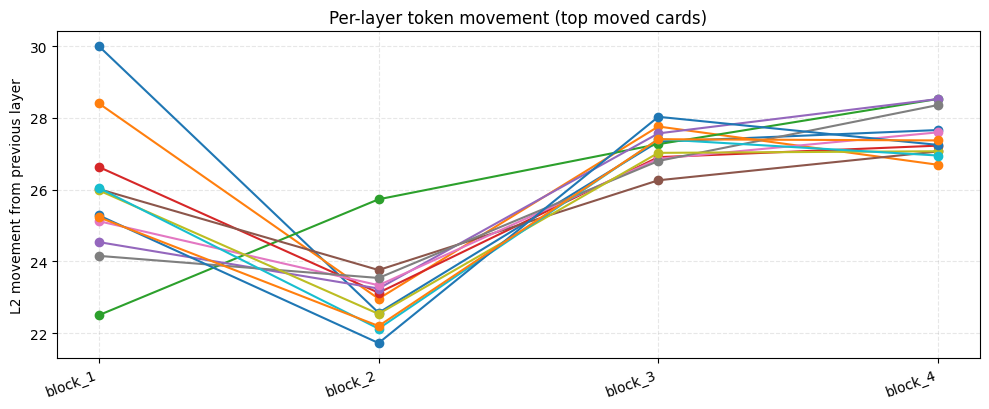

mnemonic betrayal: total movement=107.5671
volcanic island: total movement=105.8176
rhystic study: total movement=104.0279
red elemental blast: total movement=103.8878
windfall: total movement=103.8735
rite of flame: total movement=103.0989
borne upon a wind: total movement=102.9115
snap: total movement=102.8487
simian spirit guide: total movement=102.6094
final fortune: total movement=102.5271
ad nauseam: total movement=102.2809
wishclaw talisman: total movement=102.2053


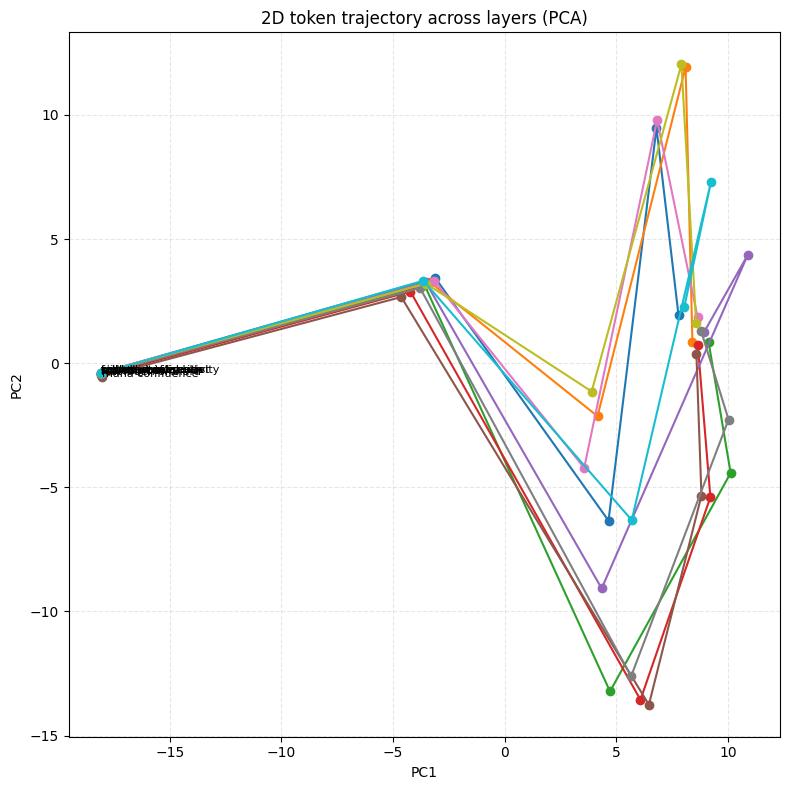

In [ ]:
def deck_to_named_tensors(deck_dict: Dict[str, int]):
    names = []
    card_ids = []
    qty_ids = []

    for name, qty in deck_dict.items():
        if qty <= 0:
            continue
        names.append(name)
        card_ids.append(vocab.get(normalize_card_name(name), 1))
        qty_ids.append(max(1, min(int(qty), MAX_QTY_EMBED)))

    names = names[:MAX_DECK_LEN]
    card_ids = card_ids[:MAX_DECK_LEN]
    qty_ids = qty_ids[:MAX_DECK_LEN]

    mask = [1] * len(card_ids)
    pad_len = MAX_DECK_LEN - len(card_ids)
    if pad_len > 0:
        card_ids += [0] * pad_len
        qty_ids += [0] * pad_len
        mask += [0] * pad_len

    c_tensor = torch.tensor([card_ids], dtype=torch.long).to(device)
    q_tensor = torch.tensor([qty_ids], dtype=torch.long).to(device)
    m_tensor = torch.tensor([mask], dtype=torch.bool).to(device)
    return names, c_tensor, q_tensor, m_tensor


def trace_token_embeddings_by_layer(model: nn.Module, deck_dict: Dict[str, int]):
    model.eval()
    names, c_tensor, q_tensor, m_tensor = deck_to_named_tensors(deck_dict)

    with torch.no_grad():
        card_vecs = model.card_embedding(c_tensor)
        card_vecs = model.card_proj(card_vecs)
        qty_vecs = model.qty_embedding(q_tensor.clamp(min=0, max=model.qty_embedding.num_embeddings - 1))
        x = card_vecs + qty_vecs

        traces = [x.squeeze(0).detach().cpu()]
        for block in model.blocks:
            x = block(x, m_tensor)
            traces.append(x.squeeze(0).detach().cpu())

    valid_len = len(names)
    traces = [t[:valid_len] for t in traces]
    layer_names = ["input"] + [f"block_{i + 1}" for i in range(len(traces) - 1)]
    return names, traces, layer_names


def plot_layerwise_token_movement(names: List[str], traces: List[torch.Tensor], layer_names: List[str], top_k: int = 20):
    if len(traces) < 2 or len(names) == 0:
        print("Not enough tokens/layers to plot movement.")
        return

    movements = []
    for i in range(1, len(traces)):
        delta = (traces[i] - traces[i - 1]).norm(dim=1).numpy()
        movements.append(delta)

    movement_arr = np.stack(movements, axis=0)
    total_movement = movement_arr.sum(axis=0)
    top_idx = np.argsort(-total_movement)[: min(top_k, len(names))]

    plt.figure(figsize=(10, max(4, 0.35 * len(top_idx))))
    for j, idx in enumerate(top_idx):
        plt.plot(range(1, len(layer_names)), movement_arr[:, idx], marker="o", linewidth=1.5)
    plt.xticks(range(1, len(layer_names)), layer_names[1:], rotation=20, ha="right")
    plt.ylabel("L2 movement from previous layer")
    plt.title("Per-layer token movement (top moved cards)")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

    top_cards = [names[i] for i in top_idx]
    for card, idx in zip(top_cards, top_idx):
        print(f"{card}: total movement={total_movement[idx]:.4f}")


def plot_token_trajectory_2d(names: List[str], traces: List[torch.Tensor], layer_names: List[str], top_k: int = 10):
    if len(names) == 0:
        print("No tokens to visualize.")
        return

    all_states = torch.cat(traces, dim=0)
    centered = all_states - all_states.mean(dim=0, keepdim=True)
    U, S, V = torch.pca_lowrank(centered, q=2)
    projected = centered @ V[:, :2]

    n_layers = len(traces)
    n_tokens = traces[0].shape[0]
    proj = projected.view(n_layers, n_tokens, 2)

    total_disp = torch.zeros(n_tokens)
    for i in range(1, n_layers):
        total_disp += (proj[i] - proj[i - 1]).norm(dim=1)

    top_idx = torch.argsort(total_disp, descending=True)[: min(top_k, n_tokens)].tolist()

    plt.figure(figsize=(8, 8))
    for idx in top_idx:
        xy = proj[:, idx, :].numpy()
        plt.plot(xy[:, 0], xy[:, 1], marker="o", linewidth=1.5)
        plt.text(xy[-1, 0], xy[-1, 1], names[idx], fontsize=8)

    plt.title("2D token trajectory across layers (PCA)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()


RUN_EMBED_TRACE_DEMO = True
TRACE_TOP_K = 12

if RUN_EMBED_TRACE_DEMO:
    ckpt = choose_inference_checkpoint()
    if ckpt is None:
        print("No checkpoint found. Load/train a model or set CHECKPOINT_TO_LOAD.")
    else:
        trace_model, _ = load_model_from_checkpoint(ckpt)
        deck_for_trace = cedh_package if "cedh_package" in globals() else parse_decklist_text(sample_decklists.get("cEDH Shell", ""))

        names, traces, layer_names = trace_token_embeddings_by_layer(trace_model, deck_for_trace)
        print(f"Tracing {len(names)} cards across {len(layer_names)} stages using {ckpt}")
        plot_layerwise_token_movement(names, traces, layer_names, top_k=TRACE_TOP_K)
        plot_token_trajectory_2d(names, traces, layer_names, top_k=min(TRACE_TOP_K, 10))

### 9: Per-Layer Synergy Attention Tracing

This section answers questions like:
1. Do combo pieces attend to each other across layers?
2. Which layer most strengthens that interaction?
3. Does a focal card remain strong when support pieces are removed?

Example focus: lion's eye diamond, brain freeze, underworld breach.

Per-layer combo attention summary:
{'layer': 1, 'query_to_key_mean': 0.045238249003887177, 'query_to_query_mean': 0.045238249003887177}
{'layer': 2, 'query_to_key_mean': 0.009714823216199875, 'query_to_query_mean': 0.009714823216199875}
{'layer': 3, 'query_to_key_mean': 0.013920707628130913, 'query_to_query_mean': 0.013920707628130913}
{'layer': 4, 'query_to_key_mean': 0.01372311357408762, 'query_to_query_mean': 0.01372311357408762}


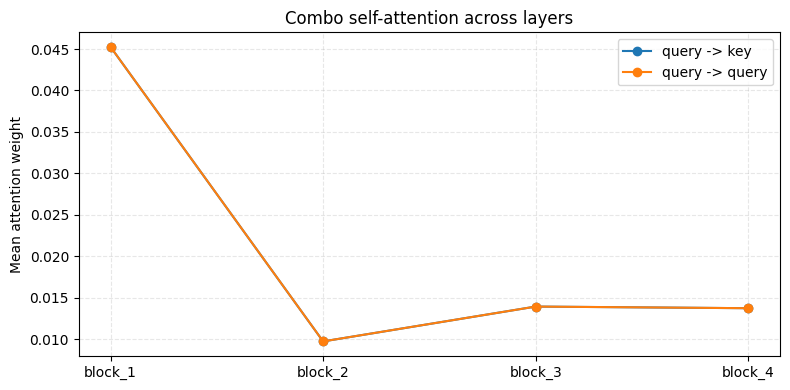

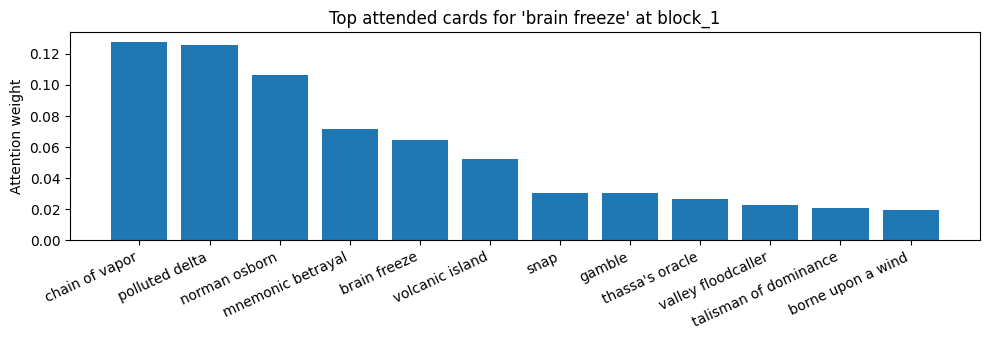

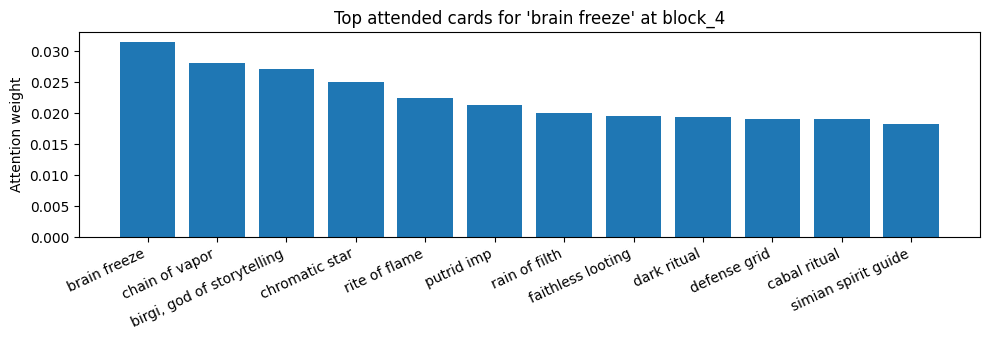

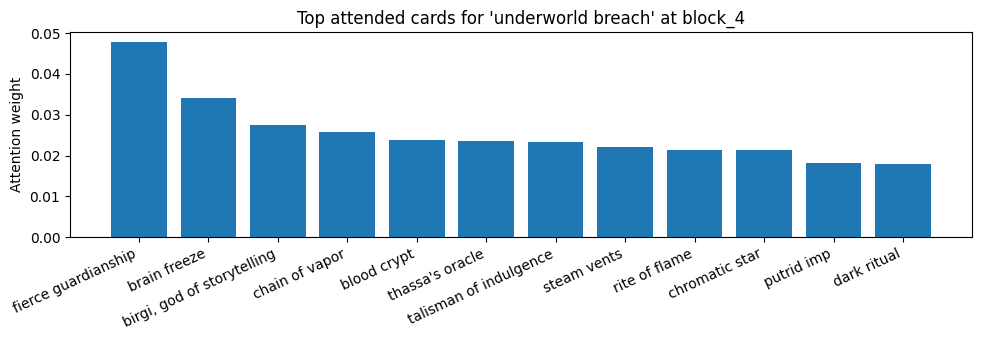


Dependency probe for 'brain freeze':
score_full: 4.9950
score_without_focal: 4.9951
score_without_support: 4.9923
score_without_support_and_focal: 4.9927
focal_marginal_with_support: -0.0001
focal_marginal_without_support: -0.0004
Interpretation: if focal_marginal_without_support is much smaller than focal_marginal_with_support, the focal card depends on support pieces.


In [ ]:
def _normalize_name_map(names: List[str]) -> Dict[str, int]:
    return {normalize_card_name(n): i for i, n in enumerate(names)}


def trace_attention_by_layer(model: MTGSetTransformerRegressor, deck_dict: Dict[str, int]):
    model.eval()
    names, c_tensor, q_tensor, m_tensor = deck_to_named_tensors(deck_dict)
    valid_len = len(names)
    if valid_len == 0:
        raise ValueError("Deck has no valid cards after parsing.")

    with torch.no_grad():
        x = model.card_embedding(c_tensor)
        x = model.card_proj(x)
        qty_vecs = model.qty_embedding(q_tensor.clamp(min=0, max=model.qty_embedding.num_embeddings - 1))
        x = x + qty_vecs

        key_padding_mask = ~m_tensor
        attn_layers = []
        for block in model.blocks:
            attn_out, attn_w = block.attn(
                x, x, x,
                key_padding_mask=key_padding_mask,
                need_weights=True,
                average_attn_weights=False,
            )
            # attn_w shape: [batch, heads, tgt_len, src_len]
            attn_layers.append(attn_w[0, :, :valid_len, :valid_len].detach().cpu())
            x = block.ln1(x + block.dropout(attn_out))
            x = block.ln2(x + block.dropout(block.mlp(x)))

    return names, attn_layers


def summarize_pair_attention(
    names: List[str],
    attn_layers: List[torch.Tensor],
    query_cards: List[str],
    key_cards: List[str],
) -> List[Dict[str, float]]:
    idx = _normalize_name_map(names)
    q_idx = [idx[normalize_card_name(c)] for c in query_cards if normalize_card_name(c) in idx]
    k_idx = [idx[normalize_card_name(c)] for c in key_cards if normalize_card_name(c) in idx]

    if not q_idx or not k_idx:
        raise ValueError("None of the requested query/key cards were found in the deck tokens.")

    rows = []
    for layer_i, attn in enumerate(attn_layers, start=1):
        # average over heads first, then selected query/key positions
        a = attn.mean(dim=0).numpy()
        qk = float(a[np.ix_(q_idx, k_idx)].mean())
        qq = float(a[np.ix_(q_idx, q_idx)].mean())
        rows.append({
            "layer": layer_i,
            "query_to_key_mean": qk,
            "query_to_query_mean": qq,
        })
    return rows


def plot_pair_attention_rows(rows: List[Dict[str, float]], title: str):
    layers = [r["layer"] for r in rows]
    qk = [r["query_to_key_mean"] for r in rows]
    qq = [r["query_to_query_mean"] for r in rows]

    plt.figure(figsize=(8, 4))
    plt.plot(layers, qk, marker="o", label="query -> key")
    plt.plot(layers, qq, marker="o", label="query -> query")
    plt.xticks(layers, [f"block_{i}" for i in layers])
    plt.ylabel("Mean attention weight")
    plt.title(title)
    plt.grid(alpha=0.3, linestyle="--")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_query_heatmap(
    names: List[str],
    attn_layers: List[torch.Tensor],
    query_card: str,
    layer_idx: int,
    top_k: int = 15,
):
    idx_map = _normalize_name_map(names)
    norm_q = normalize_card_name(query_card)
    if norm_q not in idx_map:
        raise ValueError(f"Query card not in deck tokens: {query_card}")

    if layer_idx < 1 or layer_idx > len(attn_layers):
        raise ValueError(f"layer_idx must be between 1 and {len(attn_layers)}")

    q_idx = idx_map[norm_q]
    # [heads, tgt, src] -> mean over heads, pick query row
    vec = attn_layers[layer_idx - 1].mean(dim=0)[q_idx].numpy()
    top = np.argsort(-vec)[: min(top_k, len(vec))]

    top_names = [names[i] for i in top]
    top_vals = vec[top]

    plt.figure(figsize=(10, 3.5))
    plt.bar(top_names, top_vals)
    plt.title(f"Top attended cards for '{query_card}' at block_{layer_idx}")
    plt.ylabel("Attention weight")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


def _remove_cards(deck_dict: Dict[str, int], remove_list: List[str]) -> Dict[str, int]:
    remove_norm = {normalize_card_name(c) for c in remove_list}
    out = {}
    for name, qty in deck_dict.items():
        if normalize_card_name(name) in remove_norm:
            continue
        out[name] = qty
    return out


def analyze_card_dependency(
    deck_dict: Dict[str, int],
    model_path: Path,
    focal_card: str,
    support_cards: List[str],
) -> Dict[str, float]:
    full = dict(deck_dict)
    without_focal = _remove_cards(full, [focal_card])
    without_support = _remove_cards(full, support_cards)
    without_support_and_focal = _remove_cards(without_support, [focal_card])

    s_full = predict_deck_power(full, model_path)
    s_wo_focal = predict_deck_power(without_focal, model_path)
    s_wo_support = predict_deck_power(without_support, model_path)
    s_wo_support_focal = predict_deck_power(without_support_and_focal, model_path)

    focal_delta_full = s_full - s_wo_focal
    focal_delta_wo_support = s_wo_support - s_wo_support_focal

    return {
        "score_full": s_full,
        "score_without_focal": s_wo_focal,
        "score_without_support": s_wo_support,
        "score_without_support_and_focal": s_wo_support_focal,
        "focal_marginal_with_support": focal_delta_full,
        "focal_marginal_without_support": focal_delta_wo_support,
    }


RUN_SYNERGY_TRACE_DEMO = True

if RUN_SYNERGY_TRACE_DEMO:
    ckpt = choose_inference_checkpoint()
    if ckpt is None:
        print("No checkpoint found. Load/train a model or set CHECKPOINT_TO_LOAD.")
    else:
        focus_deck = cedh_package if "cedh_package" in globals() else parse_decklist_text(sample_decklists.get("cEDH Shell", ""))
        trace_model, _ = load_model_from_checkpoint(ckpt)
        names, attn_layers = trace_attention_by_layer(trace_model, focus_deck)

        combo_cards = ["lion's eye diamond", "brain freeze", "underworld breach"]
        pair_rows = summarize_pair_attention(
            names,
            attn_layers,
            query_cards=combo_cards,
            key_cards=combo_cards,
        )
        print("Per-layer combo attention summary:")
        for r in pair_rows:
            print(r)
        plot_pair_attention_rows(pair_rows, "Combo self-attention across layers")

        # Query-specific examples: how Brain Freeze and Underworld Breach distribute attention
        plot_query_heatmap(names, attn_layers, "brain freeze", layer_idx=1, top_k=12)
        plot_query_heatmap(names, attn_layers, "brain freeze", layer_idx=len(attn_layers), top_k=12)
        plot_query_heatmap(names, attn_layers, "underworld breach", layer_idx=len(attn_layers), top_k=12)

        dep = analyze_card_dependency(
            focus_deck,
            ckpt,
            focal_card="brain freeze",
            support_cards=["underworld breach", "lion's eye diamond"],
        )
        print("\nDependency probe for 'brain freeze':")
        for k, v in dep.items():
            print(f"{k}: {v:.4f}")
        print("Interpretation: if focal_marginal_without_support is much smaller than focal_marginal_with_support, the focal card depends on support pieces.")